# 1 Импорт библиотек и функций

## 1.1 Библиотеки

In [476]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from aiomoex import get_board_candles
import asyncio
import aiohttp
from statsmodels.graphics.tsaplots import plot_acf
import ta
from sklearn.ensemble import RandomForestRegressor

## 1.2 Функции

In [485]:
def compare_industries_distributions(stock_data, industry_tickers, figsize=(20, 15)):
    """
    Сравнение распределений признаков по отраслям
    
    Parameters:
    -----------
    stock_data : dict
        Словарь с данными акций
    industry_tickers : dict
        Словарь {отрасль: [тикеры]}
    figsize : tuple
        Размер графиков
    """
    
    print("=" * 70)
    print("СРАВНЕНИЕ РАСПРЕДЕЛЕНИЙ ПО ОТРАСЛЯМ")
    print("=" * 70)
    
    # Собираем данные по отраслям
    industry_data = {}
    
    for industry, tickers in industry_tickers.items():
        industry_dfs = []
        for ticker in tickers:
            if ticker in stock_data:
                df_temp = stock_data[ticker].copy()
                df_temp['ticker'] = ticker
                df_temp['industry'] = industry
                industry_dfs.append(df_temp)
        
        if industry_dfs:
            industry_data[industry] = pd.concat(industry_dfs, ignore_index=True)
            print(f"{industry}: {len(industry_dfs)} компаний")
    
    # Определяем ключевые признаки для сравнения
    key_features = [
        'target_price_change', 'RSI_14', 'VOLATILITY_20', 
        'VOLUME_RATIO_20', 'MOM_10', 'ATR_14'
    ]
    
    # Проверяем какие признаки есть в данных
    available_features = []
    for industry_df in industry_data.values():
        available_features.extend([f for f in key_features if f in industry_df.columns])
    
    available_features = list(set(available_features))
    
    print(f"\nАнализируемые признаки: {available_features}")
    
    # Строим гистограммы для каждого признака
    n_features = len(available_features)
    n_cols = 3
    n_rows = (n_features + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    
    if n_rows == 1:
        axes = axes.flatten() if n_cols > 1 else [axes]
    else:
        axes = axes.flatten()
    
    colors = ['blue', 'red', 'green', 'orange', 'purple'][:len(industry_data)]
    
    for i, feature in enumerate(available_features):
        if i < len(axes):
            ax = axes[i]
            
            # Строим гистограммы для каждой отрасли
            for j, (industry, color) in enumerate(zip(industry_data.keys(), colors)):
                industry_df = industry_data[industry]
                if feature in industry_df.columns:
                    # Нормализуем гистограмму для сравнения форм
                    ax.hist(industry_df[feature].dropna(), 
                            bins=30, 
                            alpha=0.6, 
                            color=color, 
                            label=industry,
                            density=True,  # Нормализация для сравнения форм
                            edgecolor='black',
                            linewidth=0.5)
            
            ax.set_title(f'Распределение {feature}', fontsize=12, fontweight='bold')
            ax.set_xlabel(feature)
            ax.set_ylabel('Плотность')
            ax.legend()
            ax.grid(True, alpha=0.3)
    
    # Скрываем пустые subplots
    for i in range(len(available_features), len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    # Статистики по отраслям
    print("\n" + "=" * 70)
    print("СТАТИСТИКИ ПО ОТРАСЛЯМ")
    print("=" * 70)
    
    for feature in available_features:
        print(f"\n{feature}:")
        print("-" * 40)
        
        industry_stats = []
        
        for industry, industry_df in industry_data.items():
            if feature in industry_df.columns:
                data = industry_df[feature].dropna()
                stats = {
                    'Отрасль': industry,
                    'Среднее': data.mean(),
                    'Медиана': data.median(),
                    'Ст. откл.': data.std(),
                    'Скошенность': data.skew(),
                    'Эксцесс': data.kurtosis(),
                    'Кол-во': len(data)
                }
                industry_stats.append(stats)
        
        # Сортируем по среднему значению
        industry_stats.sort(key=lambda x: x['Среднее'])
        
        for stats in industry_stats:
            print(f"  {stats['Отрасль']:15} | Среднее: {stats['Среднее']:7.3f} | "
                  f"Ст.откл: {stats['Ст. откл.']:7.3f} | Скошенность: {stats['Скошенность']:6.2f}")
    
    # Boxplot сравнение по отраслям
    print("\n" + "=" * 70)
    print("BOXPLOT СРАВНЕНИЕ ПО ОТРАСЛЯМ")
    print("=" * 70)
    
    # Выбираем топ-6 признаков для boxplot
    top_features = available_features[:6]
    
    n_cols_box = 3
    n_rows_box = (len(top_features) + n_cols_box - 1) // n_cols_box
    
    fig, axes = plt.subplots(n_rows_box, n_cols_box, figsize=(18, 5 * n_rows_box))
    
    if n_rows_box == 1:
        axes = axes.flatten() if n_cols_box > 1 else [axes]
    else:
        axes = axes.flatten()
    
    for i, feature in enumerate(top_features):
        if i < len(axes):
            ax = axes[i]
            
            # Подготовка данных для boxplot
            boxplot_data = []
            boxplot_labels = []
            
            for industry, industry_df in industry_data.items():
                if feature in industry_df.columns:
                    boxplot_data.append(industry_df[feature].dropna())
                    boxplot_labels.append(industry)
            
            if boxplot_data:
                box = ax.boxplot(boxplot_data, labels=boxplot_labels, patch_artist=True)
                
                # Раскрашиваем boxplot
                for patch, color in zip(box['boxes'], colors):
                    patch.set_facecolor(color)
                    patch.set_alpha(0.6)
                
                ax.set_title(f'Boxplot {feature}', fontsize=12, fontweight='bold')
                ax.set_ylabel(feature)
                ax.grid(True, alpha=0.3)
                ax.tick_params(axis='x', rotation=45)
    
    # Скрываем пустые subplots
    for i in range(len(top_features), len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    return industry_data

# Пример использования с выбором отраслей:
def create_industry_groups():
    """
    Создает группы тикеров по отраслям
    """
    industry_tickers = {
        'Финансы': ['SBER', 'VTBR'],           # Банки
        'Нефтегаз': ['GAZP', 'ROSN', 'LKOH'], # Нефтегазовый сектор
        'Металлы': ['GMKN', 'TATN']           # Металлургия/добыча
    }
    return industry_tickers

In [ ]:
def analyze_relationships(df, figsize=(15, 12)):
    """
    Анализ взаимосвязей между признаками и целевыми переменными
    """
    
    # Выбираем числовые признаки
    numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
    
    print("=" * 70)
    print("АНАЛИЗ ВЗАИМОСВЯЗЕЙ И ПАТТЕРНОВ")
    print("=" * 70)
    
    # 1. Pairplot для ключевых признаков
    print("\n1. PAIRPLOT КЛЮЧЕВЫХ ПРИЗНАКОВ")
    print("-" * 40)
    
    # Выбираем наиболее информативные признаки для pairplot
    key_features = ['target_price_change', 'RSI_14', 'VOLATILITY_20', 'VOLUME_RATIO_20', 'MOM_10']
    available_features = [f for f in key_features if f in numeric_columns]
    
    if len(available_features) >= 3:
        # Добавляем TARGET_CLASS для раскраски если есть
        plot_features = available_features[:4]  # берем первые 4 чтобы не перегружать
        if 'TARGET_CLASS' in df.columns:
            plot_features = plot_features + ['TARGET_CLASS']
        
        plt.figure(figsize=(12, 10))
        sns.pairplot(df[plot_features], 
                    hue='TARGET_CLASS' if 'TARGET_CLASS' in plot_features else None,
                    diag_kind='hist',
                    palette={-1: 'red', 0: 'gray', 1: 'green'} if 'TARGET_CLASS' in plot_features else None,
                    plot_kws={'alpha': 0.6, 's': 20})
        plt.suptitle('Pairplot ключевых признаков', y=1.02)
        plt.show()
    else:
        print("Недостаточно признаков для pairplot")
    
    # 2. Scatter plot наиболее коррелирующих пар с целевой переменной
    print("\n2. SCATTER PLOT С ЦЕЛЕВЫМИ ПЕРЕМЕННЫМИ")
    print("-" * 40)
    
    # Находим топ коррелирующие признаки с target_price_change
    corr_matrix = df[numeric_columns].corr()
    if 'target_price_change' in corr_matrix.columns:
        target_correlations = corr_matrix['target_price_change'].abs().sort_values(ascending=False)
        top_correlated = target_correlations[~target_correlations.index.isin(['target_price_change', 'TARGET_CLASS'])].head(4)
        
        if len(top_correlated) >= 2:
            fig, axes = plt.subplots(2, 2, figsize=(12, 10))
            axes = axes.flatten()
            
            for i, (feature, corr) in enumerate(top_correlated.items()):
                if i < 4:
                    scatter = axes[i].scatter(df[feature], df['target_price_change'], 
                                            c=df['TARGET_CLASS'] if 'TARGET_CLASS' in df.columns else 'blue',
                                            cmap='coolwarm' if 'TARGET_CLASS' in df.columns else None,
                                            alpha=0.6, s=20)
                    axes[i].set_xlabel(feature)
                    axes[i].set_ylabel('target_price_change')
                    axes[i].set_title(f'{feature} vs target\ncorr: {corr:.3f}')
                    axes[i].grid(True, alpha=0.3)
                    
                    if 'TARGET_CLASS' in df.columns and i == 0:
                        plt.colorbar(scatter, ax=axes[i], label='TARGET_CLASS')
            
            plt.tight_layout()
            plt.show()
    
    # 6. Feature importance предварительная оценка
    print("\n3. ПРЕДВАРИТЕЛЬНАЯ ОЦЕНКА ВАЖНОСТИ ПРИЗНАКОВ")
    print("-" * 40)
    
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.model_selection import train_test_split
    
    # Подготовка данных для feature importance
    feature_columns = [col for col in numeric_columns 
                      if col not in ['target_price_change', 'TARGET_CLASS', 'target_price', 'open']]
    
    if len(feature_columns) >= 2 and 'target_price_change' in df.columns:
        X = df[feature_columns].fillna(df[feature_columns].mean())
        y = df['target_price_change']
        
        # Обучаем простую модель для оценки важности признаков
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
        
        rf = RandomForestRegressor(n_estimators=100, random_state=42)
        rf.fit(X_train, y_train)
        
        # Важность признаков
        importance_df = pd.DataFrame({
            'feature': feature_columns,
            'importance': rf.feature_importances_
        }).sort_values('importance', ascending=False)
        
        plt.figure(figsize=(10, 6))
        plt.barh(importance_df['feature'], importance_df['importance'])
        plt.xlabel('Важность признака')
        plt.title('Предварительная оценка важности признаков (Random Forest)')
        plt.gca().invert_yaxis()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        print("Топ-10 важных признаков:")
        for i, row in importance_df.head(10).iterrows():
            print(f"  {row['feature']:20}: {row['importance']:.3f}")
    
    return importance_df if 'importance_df' in locals() else None

In [443]:
def analyze_distributions(df, figsize=(15, 12)):
    """
    Комплексный анализ распределений признаков
    """
    numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
    numeric_columns = [col for col in numeric_columns if col not in ['TARGET_CLASS']]
    
    print("=" * 70)
    print("АНАЛИЗ РАСПРЕДЕЛЕНИЙ ПРИЗНАКОВ")
    print("=" * 70)
    
    # 1. Гистограммы всех признаков
    n_cols = 3
    n_rows = (len(numeric_columns) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    
    # Если одна строка, превращаем axes в 1D массив
    if n_rows == 1:
        axes = [axes] if n_cols == 1 else axes
    else:
        axes = axes.flatten()
    
    for i, column in enumerate(numeric_columns):
        if i < len(axes):
            # Гистограмма с KDE
            df[column].hist(bins=30, ax=axes[i], alpha=0.7, edgecolor='black')
            df[column].plot(kind='kde', ax=axes[i], secondary_y=True, color='red', alpha=0.7)
            axes[i].set_title(f'{column}\n(скошенность: {df[column].skew():.2f})')
            axes[i].grid(True, alpha=0.3)
    
    # Скрываем пустые subplots
    for i in range(len(numeric_columns), len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    # 2. Статистики распределений
    print("\nСТАТИСТИКИ РАСПРЕДЕЛЕНИЙ:")
    print("-" * 70)
    
    distribution_stats = []
    
    for column in numeric_columns:
        stats = {
            'Признак': column,
            'Среднее': df[column].mean(),
            'Медиана': df[column].median(),
            'Ст. откл.': df[column].std(),
            'Скошенность': df[column].skew(),
            'Эксцесс': df[column].kurtosis(),
            'Минимум': df[column].min(),
            'Максимум': df[column].max(),
            'Q1': df[column].quantile(0.25),
            'Q3': df[column].quantile(0.75)
        }
        distribution_stats.append(stats)
        
        print(f"{column:20} | Скошенность: {stats['Скошенность']:7.2f} | "
              f"Эксцесс: {stats['Эксцесс']:7.2f} | "
              f"Среднее: {stats['Среднее']:8.2f} | "
              f"Медиана: {stats['Медиана']:8.2f}")
    
    # 3. QQ-plot для проверки нормальности (топ-6 признаков)
    print(f"\nПРОВЕРКА НОРМАЛЬНОСТИ (QQ-plot):")
    print("-" * 50)
    
    import scipy.stats as stats
    
    # Выбираем признаки с наибольшим отклонением от нормальности
    skewed_features = sorted(distribution_stats, key=lambda x: abs(x['Скошенность']), reverse=True)[:6]
    
    plt.figure(figsize=(15, 10))
    
    for i, stats_dict in enumerate(skewed_features, 1):
        column = stats_dict['Признак']
        plt.subplot(2, 3, i)
        
        stats.probplot(df[column].dropna(), dist="norm", plot=plt)
        plt.title(f'{column}\nСкошенность: {stats_dict["Скошенность"]:.2f}')
        plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 4. Анализ скошенности
    print(f"\nАНАЛИЗ СКОШЕННОСТИ:")
    print("-" * 50)
    
    # Классификация по скошенности
    skew_categories = {
        'Сильно отрицательная': [],
        'Умеренно отрицательная': [],
        'Примерно нормальное': [],
        'Умеренно положительная': [],
        'Сильно положительная': []
    }
    
    for stats_dict in distribution_stats:
        skew = stats_dict['Скошенность']
        feature = stats_dict['Признак']
        
        if skew < -1:
            skew_categories['Сильно отрицательная'].append((feature, skew))
        elif -1 <= skew < -0.5:
            skew_categories['Умеренно отрицательная'].append((feature, skew))
        elif -0.5 <= skew <= 0.5:
            skew_categories['Примерно нормальное'].append((feature, skew))
        elif 0.5 < skew <= 1:
            skew_categories['Умеренно положительная'].append((feature, skew))
        else:
            skew_categories['Сильно положительная'].append((feature, skew))
    
    for category, features in skew_categories.items():
        if features:
            print(f"\n{category}:")
            for feature, skew in sorted(features, key=lambda x: x[1]):
                print(f"  {feature}: {skew:.2f}")
    
    # 5. Сравнение распределений ключевых признаков
    print(f"\nСРАВНЕНИЕ КЛЮЧЕВЫХ ПРИЗНАКОВ:")
    print("-" * 50)
    
    # Выбираем ключевые признаки для сравнения
    key_features = ['target_price_change', 'RSI_14', 'VOLATILITY_20', 'VOLUME_RATIO_20']
    available_key_features = [f for f in key_features if f in numeric_columns]
    
    if available_key_features:
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        axes = axes.flatten()
        
        for i, column in enumerate(available_key_features):
            if i < len(axes):
                # Boxplot + гистограмма
                df[column].hist(bins=30, ax=axes[i], alpha=0.7, edgecolor='black')
                axes[i].set_title(f'{column}\nСкошенность: {df[column].skew():.2f}')
                axes[i].set_xlabel(column)
                axes[i].set_ylabel('Частота')
                axes[i].grid(True, alpha=0.3)
                
                # Добавляем линии среднего и медианы
                axes[i].axvline(df[column].mean(), color='red', linestyle='--', label=f'Среднее: {df[column].mean():.2f}')
                axes[i].axvline(df[column].median(), color='green', linestyle='--', label=f'Медиана: {df[column].median():.2f}')
                axes[i].legend()
        
        # Скрываем пустые subplots
        for i in range(len(available_key_features), len(axes)):
            axes[i].set_visible(False)
        
        plt.tight_layout()
        plt.show()
    
    # 6. Рекомендации по преобразованиям
    print(f"\nРЕКОМЕНДАЦИИ ПО ПРЕОБРАЗОВАНИЯМ:")
    print("-" * 50)
    
    transformation_recommendations = []
    
    for stats_dict in distribution_stats:
        feature = stats_dict['Признак']
        skew = stats_dict['Скошенность']
        
        if abs(skew) > 1:
            recommendation = "Логарифмическое преобразование"
        elif abs(skew) > 0.5:
            recommendation = "Квадратный корень или Box-Cox"
        else:
            recommendation = "Нормальное распределение - преобразование не требуется"
        
        transformation_recommendations.append((feature, skew, recommendation))
        
        if abs(skew) > 0.5:  # Показываем только проблемные признаки
            print(f"{feature:20} | Скошенность: {skew:6.2f} | Рекомендация: {recommendation}")
    
    return distribution_stats, transformation_recommendations

In [441]:
def compare_distributions_across_stocks(stock_data, features_to_compare=None):
    """
    Сравнение распределений ключевых признаков по разным акциям
    """
    
    if features_to_compare is None:
        features_to_compare = ['target_price_change', 'RSI_14', 'VOLATILITY_20', 'VOLUME_RATIO_20']
    
    n_features = len(features_to_compare)
    fig, axes = plt.subplots(n_features, 1, figsize=(12, 4 * n_features))
    
    if n_features == 1:
        axes = [axes]
    
    for i, feature in enumerate(features_to_compare):
        # Собираем данные по всем акциям
        data_to_plot = []
        labels = []
        
        for ticker, df in stock_data.items():
            if feature in df.columns:
                data_to_plot.append(df[feature].dropna())
                labels.append(ticker)
        
        if data_to_plot:
            # Boxplot для сравнения
            axes[i].boxplot(data_to_plot, labels=labels)
            axes[i].set_title(f'Распределение {feature} по акциям')
            axes[i].set_ylabel(feature)
            axes[i].grid(True, alpha=0.3)
            axes[i].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Статистики по акциям
    print("СТАТИСТИКИ ПО АКЦИЯМ:")
    print("-" * 50)
    
    for feature in features_to_compare:
        print(f"\n{feature}:")
        for ticker, df in stock_data.items():
            if feature in df.columns:
                data = df[feature].dropna()
                print(f"  {ticker}: среднее={data.mean():.2f}, ст.откл={data.std():.2f}, "
                      f"скошенность={data.skew():.2f}")

In [427]:
def analyze_outliers(df, figsize=(15, 12)):
    """
    Комплексный анализ выбросов в данных
    """
    
    numeric_columns = df.select_dtypes(include=[np.number]).columns
    numeric_columns = [col for col in numeric_columns if col not in ['TARGET_CLASS']]  # исключаем категориальную целевую
    
    print("=" * 70)
    print("АНАЛИЗ ВЫБРОСОВ")
    print("=" * 70)
    
    # 1. Boxplot для всех признаков
    n_cols = 3
    n_rows = (len(numeric_columns) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten()
    
    for i, column in enumerate(numeric_columns):
        if i < len(axes):
            df[column].plot(kind='box', ax=axes[i], title=column)
            axes[i].grid(True, alpha=0.3)
    
    # Скрываем пустые subplots
    for i in range(len(numeric_columns), len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    # 2. Статистический анализ выбросов
    print("\nСТАТИСТИКА ВЫБРОСОВ (метод IQR):")
    print("-" * 50)
    
    outlier_stats = []
    
    for column in numeric_columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
        outlier_count = len(outliers)
        outlier_percentage = (outlier_count / len(df)) * 100
        
        outlier_stats.append({
            'Признак': column,
            'Выбросы': outlier_count,
            '%': outlier_percentage,
            'Мин': df[column].min(),
            'Макс': df[column].max(),
            'Q1': Q1,
            'Q3': Q3
        })
        
        print(f"{column:20} | Выбросы: {outlier_count:3d} ({outlier_percentage:5.1f}%) | "
              f"Границы: [{lower_bound:7.2f}, {upper_bound:7.2f}]")
    
    # 3. Анализ экстремальных значений
    print(f"\nЭКСТРЕМАЛЬНЫЕ ЗНАЧЕНИЯ:")
    print("-" * 50)
    
    for column in numeric_columns:
        if 'target_price_change' in column or 'TARGET_CLASS' in column:
            continue
            
        top_5 = df[column].nlargest(3)
        bottom_5 = df[column].nsmallest(3)
        
        print(f"\n{column}:")
        print(f"  Самые высокие: {list(top_5.values)}")
        print(f"  Самые низкие:  {list(bottom_5.values)}")
    
    # 4. Визуализация распределений с выбросами
    plt.figure(figsize=(15, 10))
    
    # Выбираем наиболее проблемные признаки (много выбросов)
    problematic_features = [stat['Признак'] for stat in outlier_stats 
                          if stat['%'] > 5][:6]  # топ-6 по количеству выбросов
    
    if problematic_features:
        for i, column in enumerate(problematic_features, 1):
            plt.subplot(2, 3, i)
            
            # Гистограмма с выделением выбросов
            Q1 = df[column].quantile(0.25)
            Q3 = df[column].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            # Разделяем на нормальные значения и выбросы
            normal_data = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)][column]
            outlier_data = df[(df[column] < lower_bound) | (df[column] > upper_bound)][column]
            
            plt.hist(normal_data, bins=30, alpha=0.7, label='Нормальные', color='blue')
            plt.hist(outlier_data, bins=10, alpha=0.7, label='Выбросы', color='red')
            plt.title(f'{column}\nВыбросы: {len(outlier_data)} ({len(outlier_data)/len(df)*100:.1f}%)')
            plt.legend()
            plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 5. Анализ выбросов в целевых переменных
    print(f"\nВЫБРОСЫ В ЦЕЛЕВЫХ ПЕРЕМЕННЫХ:")
    print("-" * 50)
    
    target_columns = [col for col in numeric_columns if 'target' in col.lower()]
    for target_col in target_columns:
        if target_col in df.columns:
            extreme_moves = df[df[target_col].abs() > 10]  # изменения > 10%
            if len(extreme_moves) > 0:
                print(f"\n{target_col}: {len(extreme_moves)} экстремальных движений (>10%)")
                print(f"  Диапазон: {extreme_moves[target_col].min():.1f}% до {extreme_moves[target_col].max():.1f}%")
    
    return outlier_stats

In [234]:
def analyze_correlations(stock_data):
    """
    Анализ корреляций между признаками и целевыми переменными
    """
    
    all_data = []
    for ticker, df in stock_data.items():
        df_temp = df.copy()
        df_temp['ticker'] = ticker
        all_data.append(df_temp)
    
    combined_df = pd.concat(all_data, ignore_index=True)
    
    numeric_columns = [
        'open', 'close', 'high', 'low', 'volume', 'value',
        'MA_7', 'MA_21', 'MA_90', 'EMA_10', 'EMA_30', 'EMA_200',
        'RSI_14', 'RSI_30', 'RSI_200', 'MOM_10', 'MOM_30', 
        'ATR_14', 'VOLATILITY_20', 'VOLATILITY_50', 'VOLUME_RATIO_20',
        'MACD', 'MACD_SIGNAL', 'MACD_HISTOGRAM',
        'target_price', 'target_price_change', 'TARGET_CLASS'
    ]
    
    existing_columns = [col for col in numeric_columns if col in combined_df.columns]
    correlation_df = combined_df[existing_columns]
    
    corr_matrix = correlation_df.corr()
    
    # 1. Большая матрица корреляций
    plt.figure(figsize=(20, 16))
    sns.heatmap(corr_matrix, cmap='coolwarm', center=0, 
                annot=True, fmt='.2f', square=True,
                cbar_kws={'shrink': 0.8})
    plt.title('Матрица корреляций (все признаки)', fontsize=16, pad=20)
    plt.tight_layout()
    plt.show()
    
    # 2. Корреляции с целевыми переменными (повернутая на 90 градусов)
    plt.figure(figsize=(16, 8))
    target_correlations = corr_matrix[['target_price_change', 'TARGET_CLASS']].drop(['target_price_change', 'TARGET_CLASS'])
    
    target_correlations_transposed = target_correlations.T
    
    sns.heatmap(target_correlations_transposed, cmap='coolwarm', center=0, 
                annot=True, fmt='.2f', square=False,
                cbar_kws={'shrink': 0.8})
    plt.title('Корреляции с целевыми переменными', fontsize=16, pad=20)
    plt.tight_layout()
    plt.show()
    
    # 3. Топ-15 признаков по корреляции с target_price_change
    plt.figure(figsize=(12, 6))
    target_corr_sorted = corr_matrix['target_price_change'].abs().sort_values(ascending=False)
    top_features = target_corr_sorted[~target_corr_sorted.index.isin(['target_price_change', 'TARGET_CLASS', 'target_price'])].head(15)
    
    plt.barh(range(len(top_features)), top_features.values)
    plt.yticks(range(len(top_features)), top_features.index)
    plt.xlabel('Абсолютная корреляция')
    plt.title('Топ-15 признаков по корреляции с target_price_change')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("=" * 70)
    print("АНАЛИЗ КОРРЕЛЯЦИЙ ПО АКЦИЯМ")
    print("=" * 70)
    
    all_ticker_correlations = {}
    
    for ticker, df in stock_data.items():
        ticker_numeric = df[existing_columns]
        ticker_corr = ticker_numeric.corr()
        
        # Корреляции с target_price_change
        ticker_target_corr = ticker_corr['target_price_change'].abs().sort_values(ascending=False)
        ticker_target_corr = ticker_target_corr[~ticker_target_corr.index.isin(['target_price_change', 'TARGET_CLASS', 'target_price'])]
        
        all_ticker_correlations[ticker] = ticker_target_corr
        
        print(f"\n{ticker} - топ-5 корреляций с target_price_change:")
        for feature, corr in ticker_target_corr.head().items():
            actual_corr = ticker_corr.loc[feature, 'target_price_change']
            print(f"  {feature}: {actual_corr:.3f}")
    
    print("\n" + "=" * 70)
    print("УСРЕДНЕННЫЕ КОРРЕЛЯЦИИ ПО ВСЕМ АКЦИЯМ")
    print("=" * 70)
    
    corr_list = []
    for ticker, correlations in all_ticker_correlations.items():
        for feature, corr in correlations.items():
            corr_list.append({'ticker': ticker, 'feature': feature, 'correlation': corr})
    
    corr_df = pd.DataFrame(corr_list)
    
    avg_correlations = corr_df.groupby('feature')['correlation'].agg(['mean', 'std', 'count']).sort_values('mean', ascending=False)
    
    print("\nТоп-15 признаков по усредненной корреляции с target_price_change:")
    for feature, row in avg_correlations.head(15).iterrows():
        print(f"  {feature}: {row['mean']:.3f} (±{row['std']:.3f})")
    
    print("\n" + "=" * 70)
    print("СИЛЬНО КОРРЕЛИРУЮЩИЕ ПАРЫ ПРИЗНАКОВ (|r| > 0.8)")
    print("=" * 70)
    
    high_corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            corr_value = corr_matrix.iloc[i, j]
            if abs(corr_value) > 0.8:
                high_corr_pairs.append((
                    corr_matrix.columns[i], 
                    corr_matrix.columns[j], 
                    corr_value
                ))
    
    if high_corr_pairs:
        high_corr_pairs_sorted = sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True)
        for feat1, feat2, corr in high_corr_pairs_sorted:
            print(f"  {feat1} - {feat2}: {corr:.3f}")
    else:
        print("  Нет сильно коррелирующих пар (|r| > 0.8)")
    
    print("\n" + "=" * 70)
    print("СТАБИЛЬНОСТЬ КОРРЕЛЯЦИЙ ПО АКЦИЯМ")
    print("=" * 70)
    
    stable_features = avg_correlations[avg_correlations['count'] == len(stock_data)].nsmallest(10, 'std')
    print("\nТоп-10 признаков со стабильными корреляциями по акциям:")
    for feature, row in stable_features.iterrows():
        print(f"  {feature}: {row['mean']:.3f} (±{row['std']:.3f})")
    
    return corr_matrix, avg_correlations

In [236]:
def plot_correlation_matrix(df, figsize=(20, 16), title='Матрица корреляций'):
    """
    Строит полную квадратную матрицу корреляций для DataFrame
    """  
    numeric_df = df.select_dtypes(include=[np.number])
    
    corr_matrix = numeric_df.corr()
    
    plt.figure(figsize=figsize)
    sns.heatmap(corr_matrix, 
                cmap='coolwarm', 
                center=0, 
                annot=True, 
                fmt='.2f',
                square=True,
                cbar_kws={'shrink': 0.8},
                annot_kws={'size': 8})
    
    plt.title(title, fontsize=16, pad=20)
    plt.tight_layout()
    plt.show()
    
    print("СИЛЬНО КОРРЕЛИРУЮЩИЕ ПАРЫ (|r| > 0.8):")
    print("=" * 50)
    
    high_corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):  # оставляем i+1 чтобы избежать дубликатов
            corr_value = corr_matrix.iloc[i, j]
            if abs(corr_value) > 0.8:
                high_corr_pairs.append((
                    corr_matrix.columns[i], 
                    corr_matrix.columns[j], 
                    corr_value
                ))
    
    if high_corr_pairs:
        high_corr_pairs_sorted = sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True)
        for feat1, feat2, corr in high_corr_pairs_sorted:
            print(f"  {feat1} - {feat2}: {corr:.3f}")
    else:
        print("  Нет сильно коррелирующих пар")
    
    return corr_matrix

In [314]:
def analyze_target_variable(stock_data):
    """
    Анализ целевой переменной target_price_change и создание категориальной переменной
    """
    
    for ticker, df in stock_data.items():
        df['TARGET_CLASS'] = np.where(df['target_price_change'] < -1, -1,
                                     np.where(df['target_price_change'] > 1, 1, 0))
    
    all_targets = []
    all_classes = []
    
    for ticker, df in stock_data.items():
        all_targets.extend(df['target_price_change'].dropna().tolist())
        all_classes.extend(df['TARGET_CLASS'].dropna().tolist())
    
    # Визуализация распределения target_price_change
    plt.figure(figsize=(15, 10))
    
    # График 1: Распределение процентных изменений
    plt.subplot(2, 3, 1)
    plt.hist(all_targets, bins=50, alpha=0.7, edgecolor='black')
    plt.title('Распределение target_price_change\n(все акции)')
    plt.xlabel('Процентное изменение за неделю (%)')
    plt.ylabel('Частота')
    plt.grid(True, alpha=0.3)
    
    # График 2: Boxplot по акциям
    plt.subplot(2, 3, 2)
    target_data = []
    ticker_labels = []
    for ticker, df in stock_data.items():
        target_data.append(df['target_price_change'].dropna())
        ticker_labels.append(ticker)
    
    plt.boxplot(target_data, labels=ticker_labels)
    plt.title('Boxplot target_price_change по акциям')
    plt.xlabel('Тикер')
    plt.ylabel('Процентное изменение (%)')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    
    # График 3: Распределение категориальной переменной
    plt.subplot(2, 3, 3)
    class_counts = pd.Series(all_classes).value_counts().sort_index()
    colors = ['red', 'gray', 'green']
    plt.bar(class_counts.index, class_counts.values, color=colors, alpha=0.7)
    plt.title('Распределение TARGET_CLASS\n(все акции)')
    plt.xlabel('Класс (-1: падение, 0: нейтр., 1: рост)')
    plt.ylabel('Количество')
    plt.xticks([-1, 0, 1], ['Падение < -1%', 'Нейтрально', 'Рост > 1%'])
    plt.grid(True, alpha=0.3)
    
    # График 4: Распределение классов по акциям
    plt.subplot(2, 3, 4)
    class_data = []
    for ticker in ticker_labels:
        df = stock_data[ticker]
        class_counts = df['TARGET_CLASS'].value_counts().sort_index()
        class_data.append([class_counts.get(-1, 0), class_counts.get(0, 0), class_counts.get(1, 0)])
    
    class_data = np.array(class_data)
    x = np.arange(len(ticker_labels))
    width = 0.25
    
    plt.bar(x - width, class_data[:, 0], width, label='Падение', color='red', alpha=0.7)
    plt.bar(x, class_data[:, 1], width, label='Нейтрально', color='gray', alpha=0.7)
    plt.bar(x + width, class_data[:, 2], width, label='Рост', color='green', alpha=0.7)
    
    plt.title('Распределение классов по акциям')
    plt.xlabel('Тикер')
    plt.ylabel('Количество')
    plt.xticks(x, ticker_labels, rotation=45)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # График 5: Статистика по акциям
    plt.subplot(2, 3, 5)
    stats_data = []
    for ticker, df in stock_data.items():
        targets = df['target_price_change'].dropna()
        stats_data.append({
            'ticker': ticker,
            'mean': targets.mean(),
            'std': targets.std(),
            'median': targets.median()
        })
    
    stats_df = pd.DataFrame(stats_data)
    x = np.arange(len(stats_df))
    
    plt.bar(x - 0.2, stats_df['mean'], 0.2, label='Среднее', alpha=0.7)
    plt.bar(x, stats_df['median'], 0.2, label='Медиана', alpha=0.7)
    plt.bar(x + 0.2, stats_df['std'], 0.2, label='Ст. откл.', alpha=0.7)
    
    plt.title('Статистики target_price_change по акциям')
    plt.xlabel('Тикер')
    plt.ylabel('Значение (%)')
    plt.xticks(x, stats_df['ticker'], rotation=45)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # График 6: Временной тренд средней доходности
    plt.subplot(2, 3, 6)
    for ticker, df in stock_data.items():
        if ticker == 'SBER':  # Пример для SBER
            df_sorted = df.sort_values('begin')
            rolling_mean = df_sorted['target_price_change'].rolling(window=30).mean()
            plt.plot(df_sorted['begin'], rolling_mean, label=ticker, linewidth=2)
    
    plt.title('Скользящее среднее target_price_change (SBER)')
    plt.xlabel('Дата')
    plt.ylabel('Среднее изменение за 30 дней (%)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Вывод статистик
    print("=" * 60)
    print("СТАТИСТИКИ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ")
    print("=" * 60)
    
    overall_targets = pd.Series(all_targets)
    print(f"Общая статистика target_price_change:")
    print(f"Среднее: {overall_targets.mean():.2f}%")
    print(f"Медиана: {overall_targets.median():.2f}%")
    print(f"Стандартное отклонение: {overall_targets.std():.2f}%")
    print(f"Минимум: {overall_targets.min():.2f}%")
    print(f"Максимум: {overall_targets.max():.2f}%")
    
    print(f"\nРаспределение классов (все акции):")
    class_dist = pd.Series(all_classes).value_counts().sort_index()
    for cls, count in class_dist.items():
        percentage = count / len(all_classes) * 100
        label = "Падение < -1%" if cls == -1 else "Нейтрально" if cls == 0 else "Рост > 1%"
        print(f"{label}: {count} ({percentage:.1f}%)")
    
    print(f"\nСтатистика по акциям:")
    stats_summary = []
    for ticker, df in stock_data.items():
        targets = df['target_price_change'].dropna()
        classes = df['TARGET_CLASS'].dropna()
        stats_summary.append({
            'Тикер': ticker,
            'Среднее %': f"{targets.mean():.2f}%",
            'Медиана %': f"{targets.median():.2f}%",
            'Волатильность %': f"{targets.std():.2f}%",
            'Падение': f"{(classes == -1).mean():.1%}",
            'Нейтрально': f"{(classes == 0).mean():.1%}",
            'Рост': f"{(classes == 1).mean():.1%}"
        })
    
    stats_df = pd.DataFrame(stats_summary)
    print(stats_df.to_string(index=False))

In [316]:
def clean_generated_features(stock_data):
    """Удаляет строки с пропусками после генерации признаков"""
    cleaned_data = {}
    
    for ticker, df in stock_data.items():
        df_clean = df.dropna().copy()
        cleaned_data[ticker] = df_clean
        
        print(f"✅ {ticker}: удалено {len(df) - len(df_clean)} строк с пропусками")
    
    return cleaned_data

In [318]:
def generate_features(stock_data):
    """
    Генерирует технические индикаторы для данных акций
    """
    
    processed_data = {}
    
    for ticker, df in stock_data.items():
        if df.empty:
            continue
            
        df_processed = df.copy().sort_values('begin')
        
        # ===== СКОЛЬЗЯЩИЕ СРЕДНИЕ =====
        df_processed['MA_7'] = df_processed['close'].rolling(window=7).mean()
        df_processed['MA_21'] = df_processed['close'].rolling(window=21).mean()
        df_processed['MA_90'] = df_processed['close'].rolling(window=90).mean()
        
        # ===== EMA =====
        df_processed['EMA_10'] = df_processed['close'].ewm(span=10).mean()
        df_processed['EMA_30'] = df_processed['close'].ewm(span=30).mean()
        df_processed['EMA_200'] = df_processed['close'].ewm(span=200).mean()
        
        # ===== RSI =====
        df_processed['RSI_14'] = ta.momentum.RSIIndicator(df_processed['close'], window=14).rsi()
        df_processed['RSI_30'] = ta.momentum.RSIIndicator(df_processed['close'], window=30).rsi()
        df_processed['RSI_90'] = ta.momentum.RSIIndicator(df_processed['close'], window=90).rsi()
        df_processed['RSI_200'] = ta.momentum.RSIIndicator(df_processed['close'], window=200).rsi()
        
        # ===== МОМЕНТУМ =====
        df_processed['MOM_10'] = ta.momentum.ROCIndicator(df_processed['close'], window=10).roc()
        df_processed['MOM_30'] = ta.momentum.ROCIndicator(df_processed['close'], window=30).roc()
        
        # ===== ATR =====
        df_processed['ATR_14'] = ta.volatility.AverageTrueRange(
            df_processed['high'], df_processed['low'], df_processed['close'], window=14
        ).average_true_range()
        
        # ===== ВОЛАТИЛЬНОСТЬ =====
        returns = df_processed['close'].pct_change()
        df_processed['VOLATILITY_20'] = returns.rolling(window=20).std() * np.sqrt(252)
        df_processed['VOLATILITY_50'] = returns.rolling(window=50).std() * np.sqrt(252)
        
        # ===== ОБЪЕМ =====
        df_processed['VOLUME_RATIO_20'] = (
            df_processed['volume'] / df_processed['volume'].rolling(window=20).mean()
        )
        
        # ===== MACD =====
        macd = ta.trend.MACD(df_processed['close'])
        df_processed['MACD'] = macd.macd()
        df_processed['MACD_SIGNAL'] = macd.macd_signal()
        df_processed['MACD_HISTOGRAM'] = macd.macd_diff()
        
        processed_data[ticker] = df_processed
        
        print(f"{ticker}: сгенерировано {len([col for col in df_processed.columns if col not in df.columns])} признаков")
    
    return processed_data

In [320]:
def add_targets(stock_data, horizon_days=7):
    """
    Добавляет целевые переменные для прогнозирования
    """
    
    for ticker, df in stock_data.items():
        if df.empty:
            continue
            
        df_sorted = df.sort_values('begin')
        
        # Цена через неделю
        df_sorted['target_price'] = df_sorted['close'].shift(-horizon_days)

        # Процентное изменение
        df_sorted['target_price_change'] = (
            (df_sorted['target_price'] / df_sorted['close'] - 1) * 100
        )
        
        stock_data[ticker] = df_sorted
        
        print(f"{ticker}: добавлены целевые переменные (горизонт {horizon_days} дней)")
    
    return stock_data

In [322]:
VALID_INTERVALS = {
    1: "1 минута",
    10: "10 минут", 
    60: "1 час",
    24: "1 день",
    7: "1 неделя",
    31: "1 месяц"
}

In [324]:
def plot_normalized_volatility_grid(stock_data, window=20, figsize=(14, 5)):
    """
    Визуализация нормализованной волатильности для каждой акции.
    
    Parameters:
    -----------
    stock_data : dict
        Словарь с данными акций
    window : int
        Окно для расчета втокорреляции (дни)
    figsize : tuple
        Размер графика (ширина, высота КАЖДОГО subplot)
    """
    
    n_tickers = len(stock_data)
    n_cols = 2
    n_rows = (n_tickers + 1) // 2
    
    total_width = figsize[0]
    total_height = figsize[1] * n_rows
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(total_width, total_height))
    
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    
    avg_volatilities = {}
    
    for idx, (ticker, df) in enumerate(stock_data.items()):
        if df.empty:
            continue
            
        row = idx // n_cols
        col = idx % n_cols
        ax = axes[row, col]
        
        df_sorted = df.sort_values('begin')
        
        returns = df_sorted['close'].pct_change()
        
        volatility = returns.rolling(window=window).std() * np.sqrt(252)
        
        normalized_vol = (volatility - volatility.min()) / (volatility.max() - volatility.min())
        
        avg_vol = volatility.mean()
        avg_volatilities[ticker] = avg_vol
        
        ax.plot(df_sorted['begin'], normalized_vol, 
                linewidth=2, 
                color='#2E86AB',
                alpha=0.8)
        
        ax.set_title(f'{ticker}\nСр. волатильность: {avg_vol:.1%}', fontsize=12)
        ax.set_xlabel('Дата')
        ax.set_ylabel('Норм. волатильность')
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='x', rotation=45)
    
    for idx in range(n_tickers, n_rows * n_cols):
        row = idx // n_cols
        col = idx % n_cols
        axes[row, col].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    print("Средняя годовая волатильность по акциям:")
    print("-" * 40)
    for ticker, vol in sorted(avg_volatilities.items(), key=lambda x: x[1], reverse=True):
        print(f"{ticker}: {vol:.1%}")
    
    print(f"\nМаксимальная: {max(avg_volatilities.values()):.1%}")
    print(f"Минимальная: {min(avg_volatilities.values()):.1%}")
    print(f"Средняя: {np.mean(list(avg_volatilities.values())):.1%}")

In [326]:
def plot_autocorrelation_periods(stock_data, n_periods=3, lags=50, figsize=(12, 5)):
    """
    Визуализация автокорреляции цен закрытия по временным периодам.
    
    Разбивает данные каждого тикера на равные периоды и строит графики
    автокорреляционной функции для анализа изменения поведения акций во времени.
    
    Parameters:
    -----------
    stock_data : dict
        Словарь с данными, где ключи - тикеры, значения - DataFrame с колонками:
        'begin' (дата) и 'close' (цена закрытия)
    n_periods : int, default=3
        Количество периодов для разбиения данных
    lags : int, default=50
        Количество лагов для анализа автокорреляции
    figsize : tuple, default=(15, 5)
        Размер фигуры для каждого тикера
    """
    
    plt.rcParams.update({
        'font.size': 12,
        'axes.titlesize': 14,
        'axes.labelsize': 12,
        'xtick.labelsize': 10,
        'ytick.labelsize': 10
    })
    
    for ticker, df in stock_data.items():
        if df.empty:
            continue
            
        df_sorted = df.sort_values('begin')
        total_days = len(df_sorted)
        period_size = total_days // n_periods
        
        fig, axes = plt.subplots(1, n_periods, figsize=(figsize[0], figsize[1]))
        
        if n_periods == 1:
            axes = [axes]
        
        for period in range(n_periods):
            start_idx = period * period_size
            end_idx = (period + 1) * period_size if period < n_periods - 1 else total_days
            
            period_data = df_sorted.iloc[start_idx:end_idx]
            close_prices = period_data['close']
            
            start_date = period_data['begin'].iloc[0].strftime('%Y-%m-%d')
            end_date = period_data['begin'].iloc[-1].strftime('%Y-%m-%d')
            
            plot_acf(close_prices, ax=axes[period], lags=lags, alpha=0.05)
            
            axes[period].set_title(f'{ticker} - Период {period+1}\n{start_date} - {end_date}', 
                                 fontsize=14, pad=20)
            axes[period].set_xlabel('Лаг', fontsize=12)
            axes[period].set_ylabel('Автокорреляция', fontsize=12)
            axes[period].grid(True, alpha=0.3)
            
            axes[period].tick_params(axis='both', which='major', labelsize=10)
        
        plt.tight_layout()
        plt.show()

In [328]:
async def fetch_ticker_data(session: aiohttp.ClientSession, ticker: str, interval: int, start_date: str, end_date: str) -> dict[str, pd.DataFrame]:
    try:
        res = await get_board_candles(session, ticker, interval, start_date, end_date)
        if res:
            df = pd.DataFrame(res)
            
            if 'end' in df.columns:
                df = df.drop('end', axis=1)
            
            df['begin'] = pd.to_datetime(df['begin'])
            
            if interval in [24, 7, 31]:
                df['begin'] = df['begin'].dt.normalize()

            if 'begin' in df.columns:
                cols = ['begin'] + [col for col in df.columns if col != 'begin']
                df = df[cols]
            
            df['ticker'] = ticker
            return {ticker: df}
        else:
            return {ticker: pd.DataFrame()}
    except Exception as e:
        print(f'Ошибка парсинга. Не удалось получить данные для {ticker}, {e}')
        return {ticker: pd.DataFrame()}

async def get_moex_data(tickers: list[str], start_date: str, end_date: str, interval: int = 24) -> dict[str, pd.DataFrame]:
    if interval not in VALID_INTERVALS:
        raise ValueError(f"Неверный интервал. Допустимые значения: {list(VALID_INTERVALS.keys())}")
    
    async with aiohttp.ClientSession() as session:
        coros = [fetch_ticker_data(session, ticker, interval, start_date, end_date) for ticker in tickers]
        stock_data = await asyncio.gather(*coros)
    
    stock_data_dict = {k: v for d in stock_data for k, v in d.items()}
    return stock_data_dict

In [330]:
def plot_enhanced_ticker_charts(stock_data, figsize=(16, 8)):
    """
    Строит расширенные графики для каждого тикера с дополнительной информацией
    
    Parameters:
    -----------
    stock_data : dict
        Словарь с данными
    figsize : tuple
        Размер каждого графика
    """
    
    colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3F7CAC']
    
    for i, (ticker, df) in enumerate(stock_data.items()):
        if df.empty:
            continue
            
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize)
        
        df = df.sort_values('begin')
        
        color = colors[i % len(colors)]
        ax1.plot(df['begin'], df['close'], 
                linewidth=2.5, 
                color=color,
                label='Цена закрытия')
        
        ax1.set_title(f'Акции {ticker} - Анализ цен', fontsize=16, fontweight='bold', pad=20)
        ax1.set_ylabel('Цена (руб)', fontsize=12)
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        ax2.bar(df['begin'], df['volume'], 
               color=color, 
               alpha=0.6,
               label='Объем торгов')
        
        ax2.set_xlabel('Дата', fontsize=12)
        ax2.set_ylabel('Объем', fontsize=12)
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        ax2.tick_params(axis='x', rotation=45)
        
        plt.tight_layout()
        plt.show()

# 2 Подготовка данных

## 2.1 Парсинг данных по "Голубым фишкам" c 2022-05-01

In [334]:
tickers = ['SBER', 'GAZP', 'LKOH', 'ROSN', 'YDEX', 'VTBR', 'TATN', 'GMKN']
stock_data = await get_moex_data(
    tickers,
    start_date='2022-05-01', 
    end_date='2025-10-01', 
    interval=24
)

## 2.2 Генерация признаков

In [336]:
stock_data_with_features = generate_features(stock_data)
print()
stock_data_with_targets = add_targets(stock_data_with_features, horizon_days=7)

SBER: сгенерировано 19 признаков
GAZP: сгенерировано 19 признаков
LKOH: сгенерировано 19 признаков
ROSN: сгенерировано 19 признаков
YDEX: сгенерировано 19 признаков
VTBR: сгенерировано 19 признаков
TATN: сгенерировано 19 признаков
GMKN: сгенерировано 19 признаков

SBER: добавлены целевые переменные (горизонт 7 дней)
GAZP: добавлены целевые переменные (горизонт 7 дней)
LKOH: добавлены целевые переменные (горизонт 7 дней)
ROSN: добавлены целевые переменные (горизонт 7 дней)
YDEX: добавлены целевые переменные (горизонт 7 дней)
VTBR: добавлены целевые переменные (горизонт 7 дней)
TATN: добавлены целевые переменные (горизонт 7 дней)
GMKN: добавлены целевые переменные (горизонт 7 дней)


In [339]:
stock_data_with_targets['SBER'].iloc[400:405]

,begin,open,close,high,low,value,volume,ticker,MA_7,MA_21,...,MOM_30,ATR_14,VOLATILITY_20,VOLATILITY_50,VOLUME_RATIO_20,MACD,MACD_SIGNAL,MACD_HISTOGRAM,target_price,target_price_change
400,2023-11-29,279.36,276.80,280.56,276.20,8.285652e+09,29820830,SBER,283.004286,279.141429,...,3.322135,4.263755,0.160814,0.143779,0.824268,3.321788,4.179204,-0.857415,265.16,-4.205202
401,2023-11-30,276.70,277.50,278.65,272.75,1.539141e+10,55873540,SBER,282.248571,279.513810,...,3.294249,4.380630,0.160272,0.139029,1.482659,2.790366,3.901436,-1.111070,256.89,-7.427027
402,2023-12-01,277.00,273.97,277.98,273.55,8.726777e+09,31660970,SBER,280.507143,279.747619,...,1.545589,4.384156,0.167817,0.142409,0.828417,2.060615,3.533272,-1.472657,257.60,-5.975107
403,2023-12-04,273.60,270.96,274.95,270.52,1.027482e+10,37700740,SBER,278.331429,279.862857,...,0.318401,4.387431,0.160111,0.145212,0.975692,1.225276,3.071673,-1.846397,260.45,-3.878801
404,2023-12-05,271.98,279.62,279.65,270.54,1.289872e+10,46892570,SBER,277.298571,280.158095,...,3.078114,4.724757,0.197061,0.158687,1.191048,1.247672,2.706873,-1.459201,256.64,-8.218296


# 3 Анализ 

## 3.1 Первичный анализ

### 3.1.1 Структура данных

Базовые признаки

1. Временные метки
- **`begin`** - Дата и время начала торгового периода

2. Ценовые характеристики
- **`open`** - Цена открытия торгового периода
- **`close`** - Цена закрытия торгового периода  
- **`high`** - Максимальная цена за период
- **`low`** - Минимальная цена за период

3. Объемные показатели
- **`volume`** - Объем торгов в штуках акций
- **`value`** - Объем торгов в денежном выражении (рубли)

4. Идентификаторы
- **`ticker`** - Идентификатор ценной бумаги (например, SBER)

Типы данных

| Признак | Тип данных | Описание |
|---------|------------|----------|
| `begin` | DateTime | Временная метка |
| `open`, `close`, `high`, `low`, `value` | Float64 | Финансовые показатели |
| `volume` | Int64 | Количество акций |
| `ticker` | String | Идентификатор эмитента |

Сгенерированные технические индикаторы

Трендовые индикаторы
| Признак | Описание |
|---------|----------|
| `MA_7` | Простая скользящая средняя за 7 дней |
| `MA_21` | Простая скользящая средняя за 21 день |
| `MA_90` | Простая скользящая средняя за 90 дней |
| `EMA_10` | Экспоненциальная скользящая средняя за 10 дней |
| `EMA_30` | Экспоненциальная скользящая средняя за 30 дней |
| `EMA_200` | Экспоненциальная скользящая средняя за 200 дней |

Моментум-индикаторы
| Признак | Описание |
|---------|----------|
| `RSI_14` | Индекс относительной силы за 14 дней |
| `RSI_30` | Индекс относительной силы за 30 дней |
| `RSI_90` | Индекс относительной силы за 90 дней |
| `RSI_200` | Индекс относительной силы за 200 дней |
| `MOM_10` | Моментум изменения цены за 10 дней |
| `MOM_30` | Моментум изменения цены за 30 дней |

Волатильность
| Признак | Описание |
|---------|----------|
| `ATR_14` | Average True Range - средний истинный диапазон за 14 дней |
| `VOLATILITY_20` | Годовая волатильность за 20 дней |
| `VOLATILITY_50` | Годовая волатильность за 50 дней |

Объемные индикаторы
| Признак | Описание |
|---------|----------|
| `VOLUME_RATIO_20` | Отношение объема к 20-дневной средней |

MACD индикатор
| Признак | Описание |
|---------|----------|
| `MACD` | Линия MACD (12,26) |
| `MACD_SIGNAL` | Сигнальная линия MACD (9) |
| `MACD_HISTOGRAM` | Гистограмма MACD |

Целевые переменные
| Признак | Описание |
|---------|----------|
| `TARGET_PCT_CHANGE` | Процентное изменение цены через 7 дней |

In [348]:
stock_data_with_targets['SBER'].head()

,begin,open,close,high,low,value,volume,ticker,MA_7,MA_21,...,MOM_30,ATR_14,VOLATILITY_20,VOLATILITY_50,VOLUME_RATIO_20,MACD,MACD_SIGNAL,MACD_HISTOGRAM,target_price,target_price_change
0,2022-05-04,129.10,123.20,131.50,122.50,8.444076e+09,67289000,SBER,NaN,NaN,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,127.75,3.693182
1,2022-05-05,124.21,124.80,125.54,122.75,5.266724e+09,42383000,SBER,NaN,NaN,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,125.12,0.256410
2,2022-05-06,124.74,123.10,124.99,121.52,3.758706e+09,30602500,SBER,NaN,NaN,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,125.60,2.030869
3,2022-05-11,123.00,123.34,126.05,121.86,4.074118e+09,32870440,SBER,NaN,NaN,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,122.20,-0.924274
4,2022-05-12,123.10,119.15,123.74,118.05,3.736762e+09,30846460,SBER,NaN,NaN,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,119.46,0.260176


### 3.1.2 Анализ пропусков 

In [351]:
for ticker in tickers:
    print(f"В данных {ticker} {stock_data_with_targets[ticker].isna().sum().sum()} прокусков")

В данных SBER 679 прокусков
В данных GAZP 679 прокусков
В данных LKOH 679 прокусков
В данных ROSN 679 прокусков
В данных YDEX 679 прокусков
В данных VTBR 679 прокусков
В данных TATN 679 прокусков
В данных GMKN 679 прокусков


In [353]:
for col in stock_data_with_targets['SBER']:
    print(f"В признаке {col} {stock_data_with_targets['SBER'][col].isna().sum()} прокусков")

В признаке begin 0 прокусков
В признаке open 0 прокусков
В признаке close 0 прокусков
В признаке high 0 прокусков
В признаке low 0 прокусков
В признаке value 0 прокусков
В признаке volume 0 прокусков
В признаке ticker 0 прокусков
В признаке MA_7 6 прокусков
В признаке MA_21 20 прокусков
В признаке MA_90 89 прокусков
В признаке EMA_10 0 прокусков
В признаке EMA_30 0 прокусков
В признаке EMA_200 0 прокусков
В признаке RSI_14 13 прокусков
В признаке RSI_30 29 прокусков
В признаке RSI_90 89 прокусков
В признаке RSI_200 199 прокусков
В признаке MOM_10 10 прокусков
В признаке MOM_30 30 прокусков
В признаке ATR_14 0 прокусков
В признаке VOLATILITY_20 20 прокусков
В признаке VOLATILITY_50 50 прокусков
В признаке VOLUME_RATIO_20 19 прокусков
В признаке MACD 25 прокусков
В признаке MACD_SIGNAL 33 прокусков
В признаке MACD_HISTOGRAM 33 прокусков
В признаке target_price 7 прокусков
В признаке target_price_change 7 прокусков


### Вывод

В большинстве сгенерированных признаков есть пропуски, но их появление очевидно, пропуски получаются из за скользящего окна, так как для рассчета некотрых признаков нужны все измерения за период окна, например, за 200 дней. </br>
Все строки с пропусками прийдется удалить

In [357]:
data = clean_generated_features(stock_data_with_features)

✅ SBER: удалено 206 строк с пропусками
✅ GAZP: удалено 206 строк с пропусками
✅ LKOH: удалено 206 строк с пропусками
✅ ROSN: удалено 206 строк с пропусками
✅ YDEX: удалено 206 строк с пропусками
✅ VTBR: удалено 206 строк с пропусками
✅ TATN: удалено 206 строк с пропусками
✅ GMKN: удалено 206 строк с пропусками


Также, на этапе данного анализа можно удалить первоночальные признаки стоимости акций, так как они анализировались в другом ноутбуке и оставить только сгенерированные, которые будут использоваться в модели

In [360]:
for ticker in tickers:
    data[ticker].drop(['ticker', 'close', 'high', 'low', 'value', 'volume'], axis=1, inplace=True)

### 3.1.3 Типы данных и описательные статистики

In [363]:
data['SBER'].info()

<class 'pandas.core.frame.DataFrame'>
Index: 709 entries, 199 to 907
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   begin                709 non-null    datetime64[ns]
 1   open                 709 non-null    float64       
 2   MA_7                 709 non-null    float64       
 3   MA_21                709 non-null    float64       
 4   MA_90                709 non-null    float64       
 5   EMA_10               709 non-null    float64       
 6   EMA_30               709 non-null    float64       
 7   EMA_200              709 non-null    float64       
 8   RSI_14               709 non-null    float64       
 9   RSI_30               709 non-null    float64       
 10  RSI_90               709 non-null    float64       
 11  RSI_200              709 non-null    float64       
 12  MOM_10               709 non-null    float64       
 13  MOM_30               709 non-null    f

In [365]:
data['SBER'].drop(columns=['begin']).describe()

,open,MA_7,MA_21,MA_90,EMA_10,EMA_30,EMA_200,RSI_14,RSI_30,RSI_90,...,MOM_30,ATR_14,VOLATILITY_20,VOLATILITY_50,VOLUME_RATIO_20,MACD,MACD_SIGNAL,MACD_HISTOGRAM,target_price,target_price_change
count,709.000000,709.000000,709.000000,709.000000,709.000000,709.000000,709.000000,709.000000,709.000000,709.000000,...,709.000000,709.000000,709.000000,709.000000,709.000000,709.000000,709.000000,709.000000,709.000000,709.000000
mean,277.528702,277.004469,275.567857,267.335650,276.689876,274.487538,255.038728,54.773887,55.059796,55.413034,...,3.386272,5.147832,0.216283,0.226509,1.002193,1.536371,1.581714,-0.045342,278.829168,0.671475
std,35.510704,35.811341,37.051394,43.306677,35.899419,37.412128,44.970375,13.445972,10.290860,6.581020,...,9.459299,1.343340,0.094387,0.071622,0.597750,4.594330,4.351246,1.303225,33.357978,4.246959
min,157.330000,160.524286,157.680952,138.824667,160.417997,155.302753,137.232694,19.435570,28.184889,40.466785,...,-17.249360,2.671033,0.064857,0.104378,0.017720,-10.799749,-9.649335,-4.891022,164.300000,-12.406826
25%,257.600000,256.560000,257.330000,252.685778,257.292159,256.379716,231.619515,46.417453,48.832002,51.534508,...,-2.271881,4.039647,0.144737,0.178485,0.638141,-0.802638,-0.735601,-0.748527,258.210000,-1.698089
50%,280.440000,280.055714,278.261905,274.913556,279.222095,275.825227,271.023079,55.102589,55.707174,55.812694,...,2.384593,5.008244,0.203192,0.228602,0.885185,1.533704,1.500931,-0.131604,281.440000,0.448042
75%,308.880000,308.670000,308.212857,304.412000,308.371464,306.551914,288.449682,63.820016,61.484601,59.827615,...,7.011798,6.106986,0.273159,0.254828,1.219896,3.939607,3.915532,0.588272,308.890000,2.631065
max,328.580000,326.805714,320.781905,312.728000,324.351298,320.315085,304.736760,90.092986,82.486171,71.288148,...,38.624000,9.481344,0.554931,0.411090,4.573474,13.566188,12.242975,5.379135,328.370000,20.740952


### 3.1.4 Проверка дубликатов

In [368]:
for ticker in tickers:
    print(f"В данных {ticker} {data[ticker].duplicated().sum()} дубликатов") 

В данных SBER 0 дубликатов
В данных GAZP 0 дубликатов
В данных LKOH 0 дубликатов
В данных ROSN 0 дубликатов
В данных YDEX 0 дубликатов
В данных VTBR 0 дубликатов
В данных TATN 0 дубликатов
В данных GMKN 0 дубликатов


In [370]:
data['SBER'].columns

Index(['begin', 'open', 'MA_7', 'MA_21', 'MA_90', 'EMA_10', 'EMA_30',
       'EMA_200', 'RSI_14', 'RSI_30', 'RSI_90', 'RSI_200', 'MOM_10', 'MOM_30',
       'ATR_14', 'VOLATILITY_20', 'VOLATILITY_50', 'VOLUME_RATIO_20', 'MACD',
       'MACD_SIGNAL', 'MACD_HISTOGRAM', 'target_price', 'target_price_change'],
      dtype='object')

## 3.2 Анализ целевой переменной

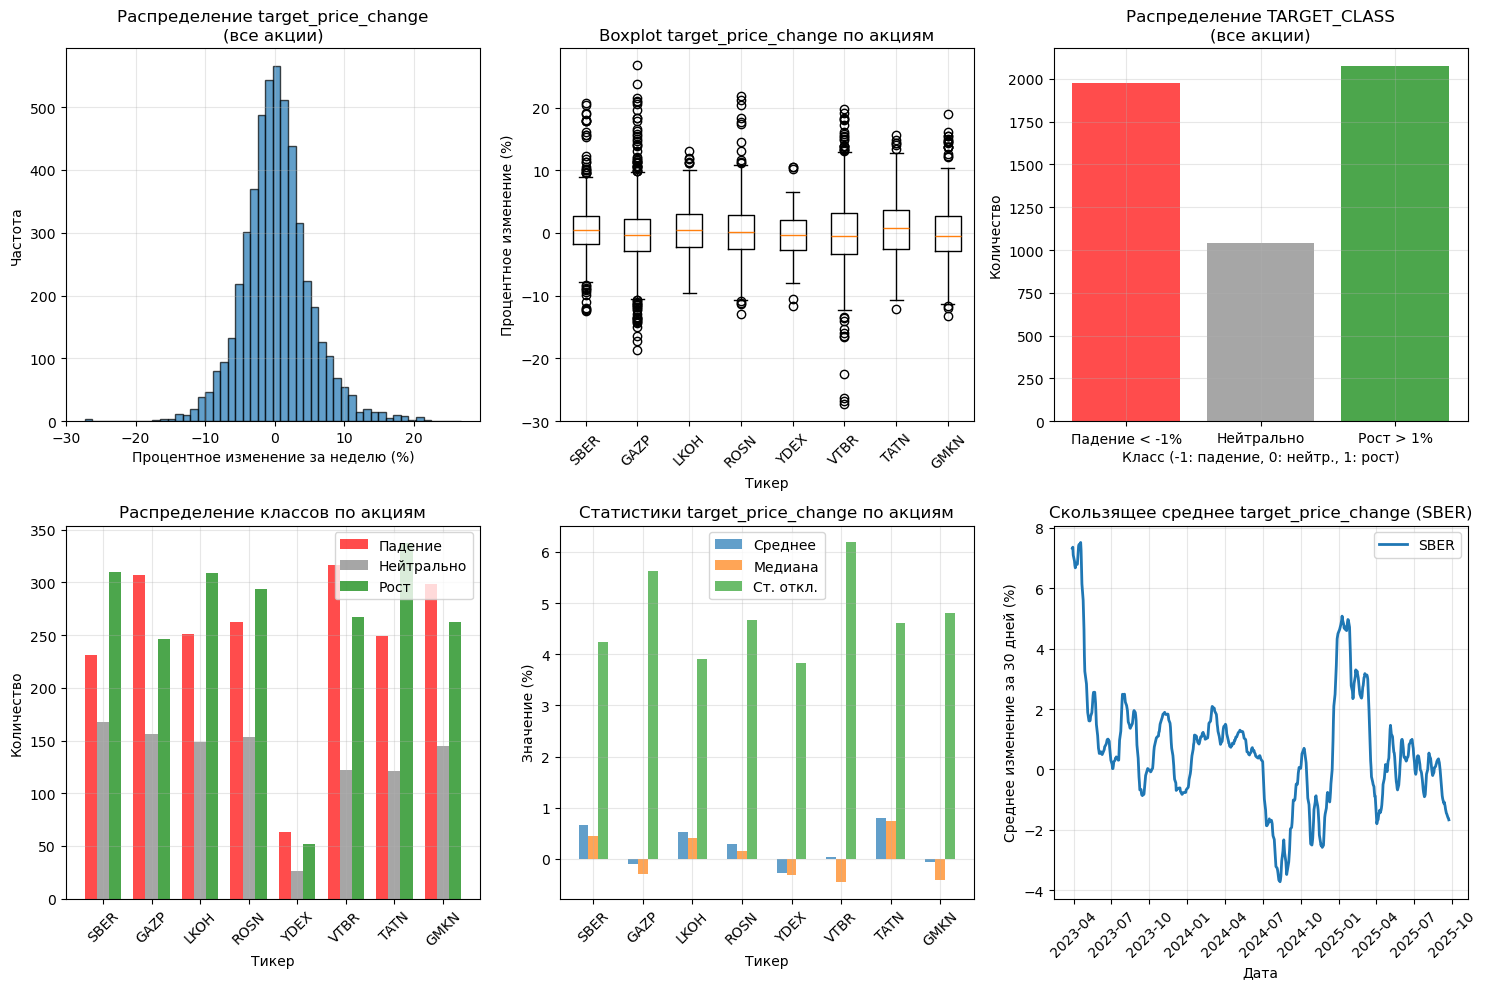

СТАТИСТИКИ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ
Общая статистика target_price_change:
Среднее: 0.29%
Медиана: 0.09%
Стандартное отклонение: 4.90%
Минимум: -27.31%
Максимум: 26.81%

Распределение классов (все акции):
Падение < -1%: 1977 (38.8%)
Нейтрально: 1040 (20.4%)
Рост > 1%: 2077 (40.8%)

Статистика по акциям:
Тикер Среднее % Медиана % Волатильность % Падение Нейтрально  Рост
 SBER     0.67%     0.45%           4.25%   32.6%      23.7% 43.7%
 GAZP    -0.11%    -0.29%           5.63%   43.3%      22.0% 34.7%
 LKOH     0.53%     0.41%           3.91%   35.4%      21.0% 43.6%
 ROSN     0.29%     0.15%           4.67%   37.0%      21.6% 41.5%
 YDEX    -0.27%    -0.31%           3.83%   44.7%      18.4% 36.9%
 VTBR     0.03%    -0.45%           6.18%   44.8%      17.3% 37.9%
 TATN     0.79%     0.74%           4.62%   35.2%      17.1% 47.7%
 GMKN    -0.05%    -0.41%           4.80%   42.3%      20.6% 37.2%


In [373]:
analyze_target_variable(data)

## Вывод

Распределение целевой переменной больше похоже на нормальное, значения целевой переменной по каждой бумаге отдельно сильно не выделяются

Есть идея сдеклать целевую переменную категориальной:
- падение акции более чем на 1% класс '-1'
- рост акции более чем на 1% класс '1'
- иначе класс 0

Порог можно всегда варьировать

## 3.3 Корреляционный анализ

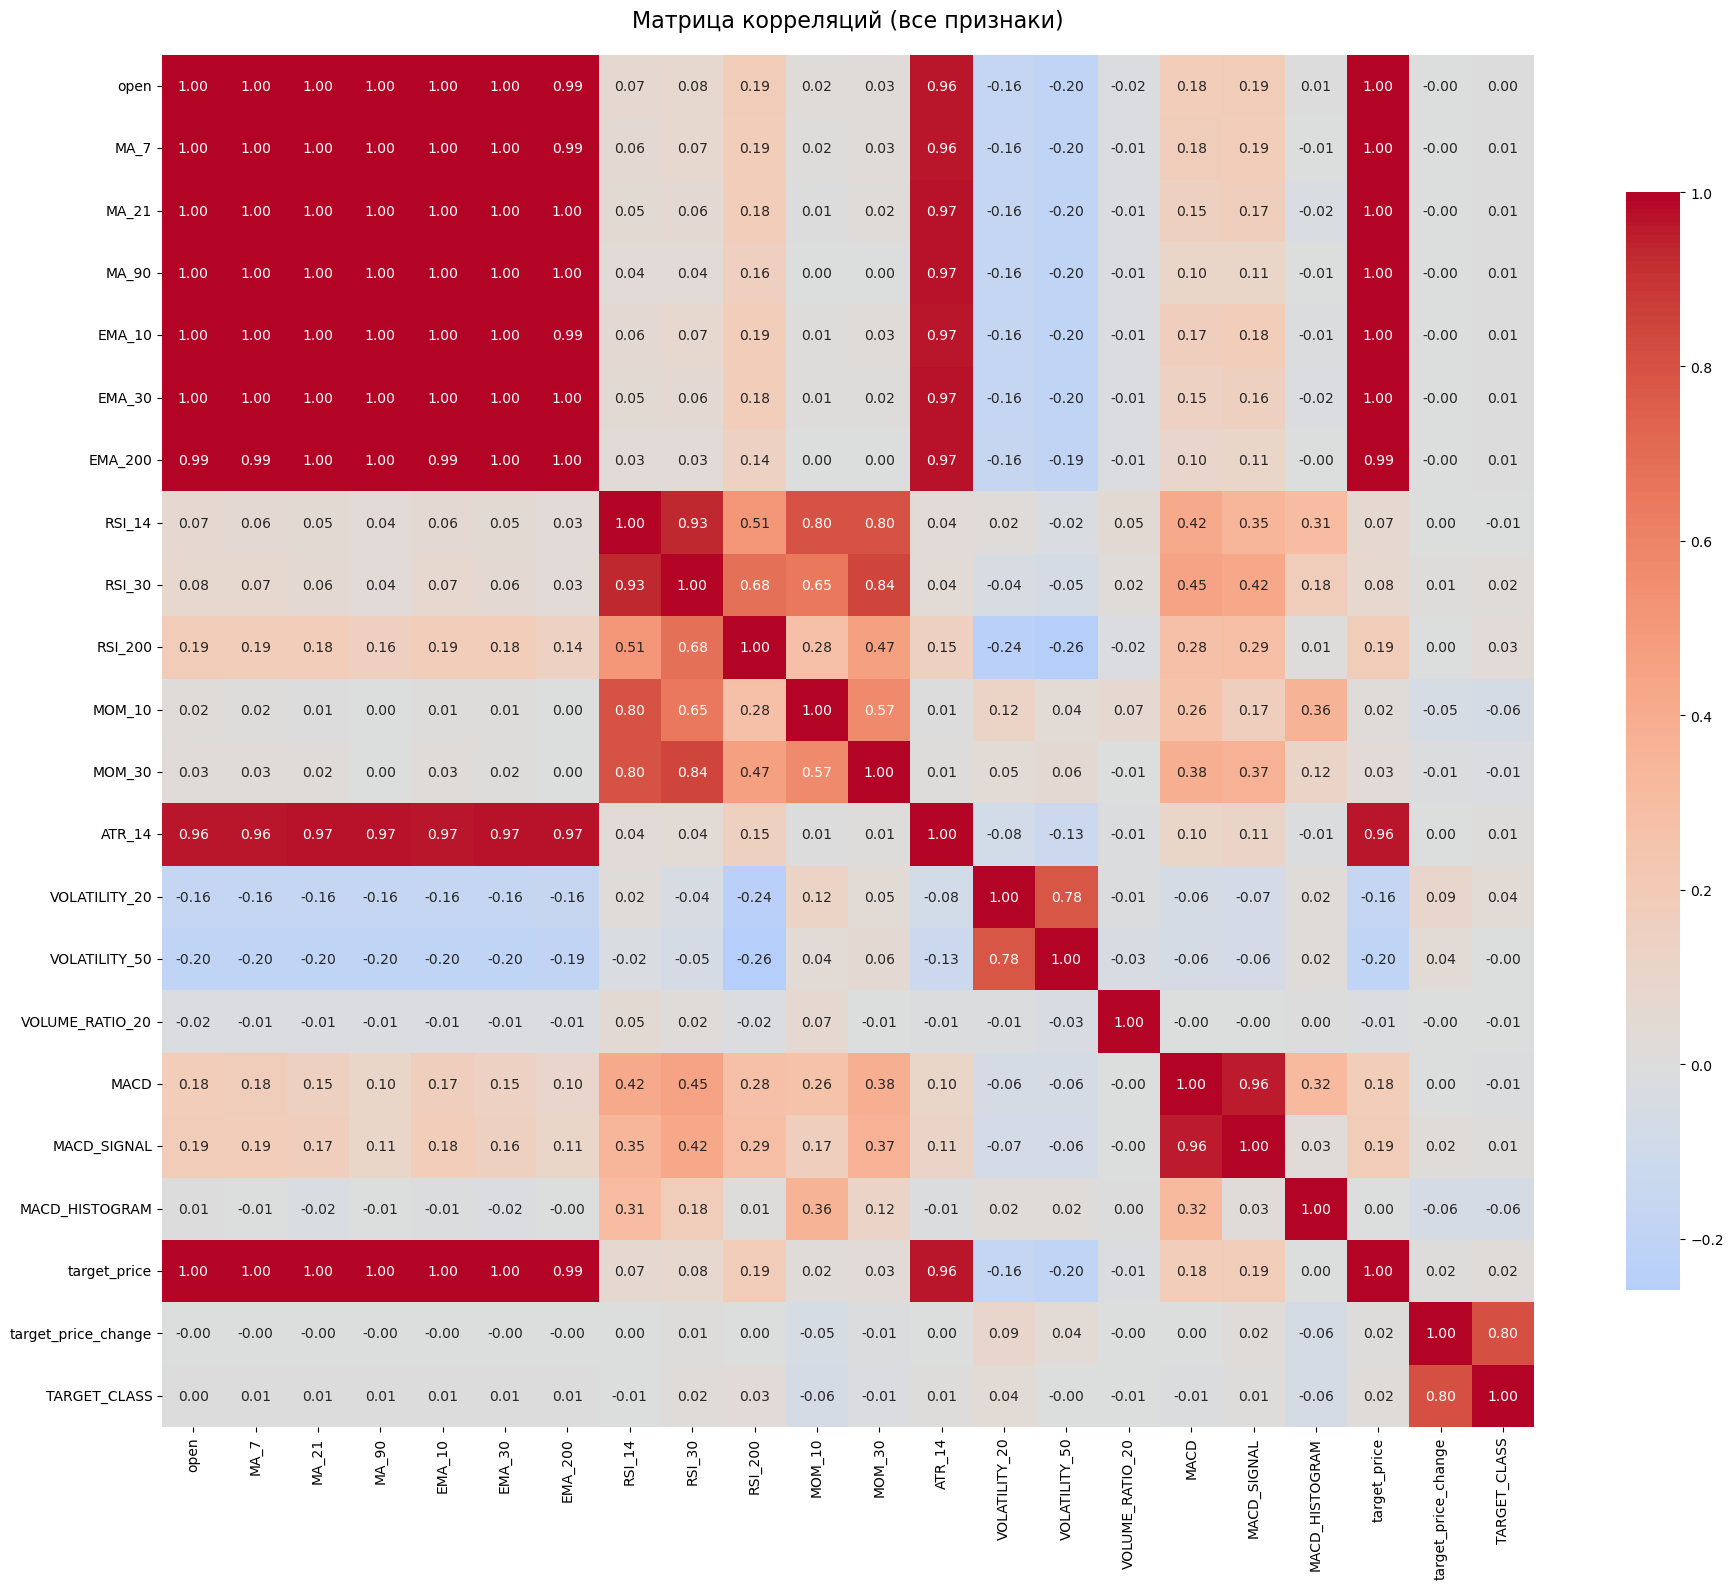

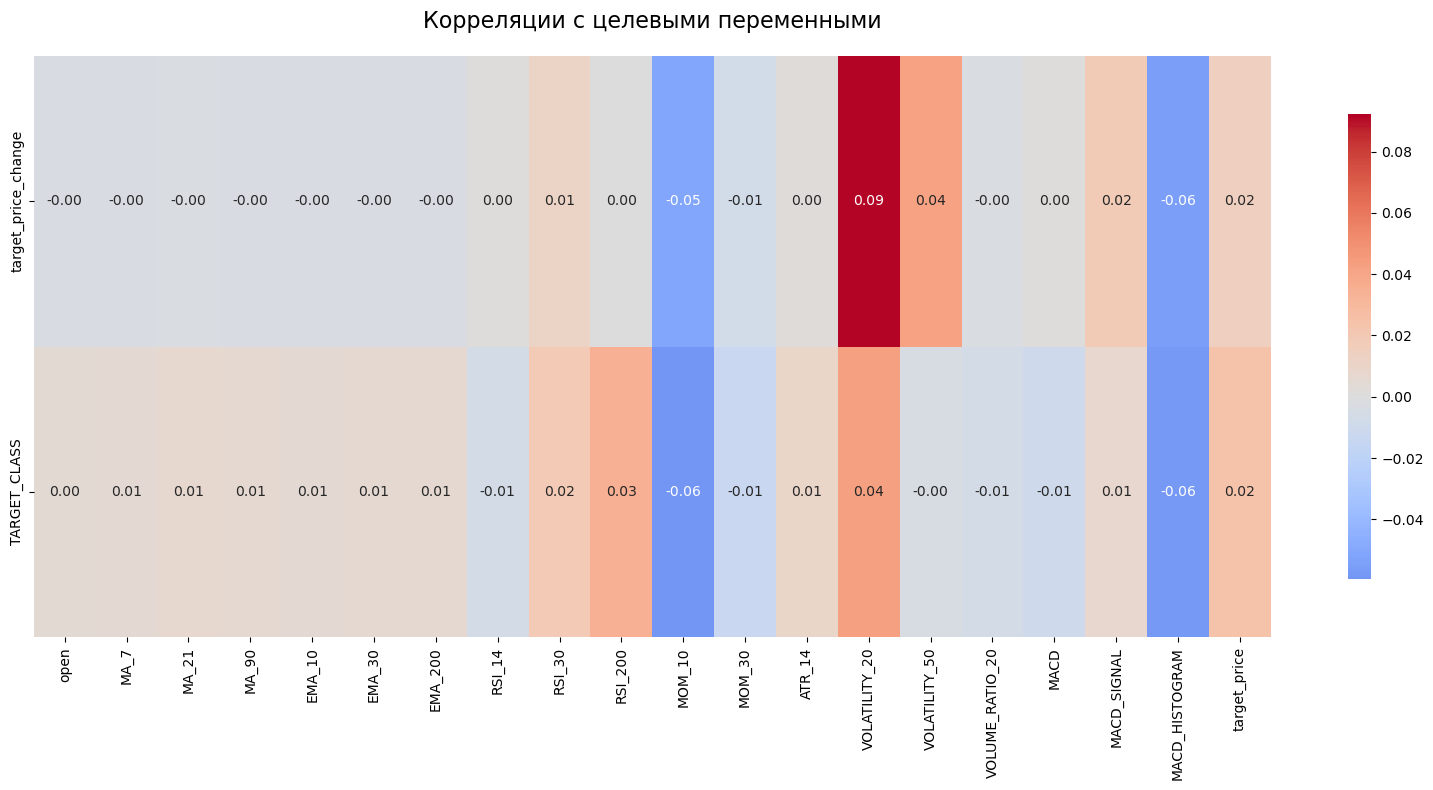

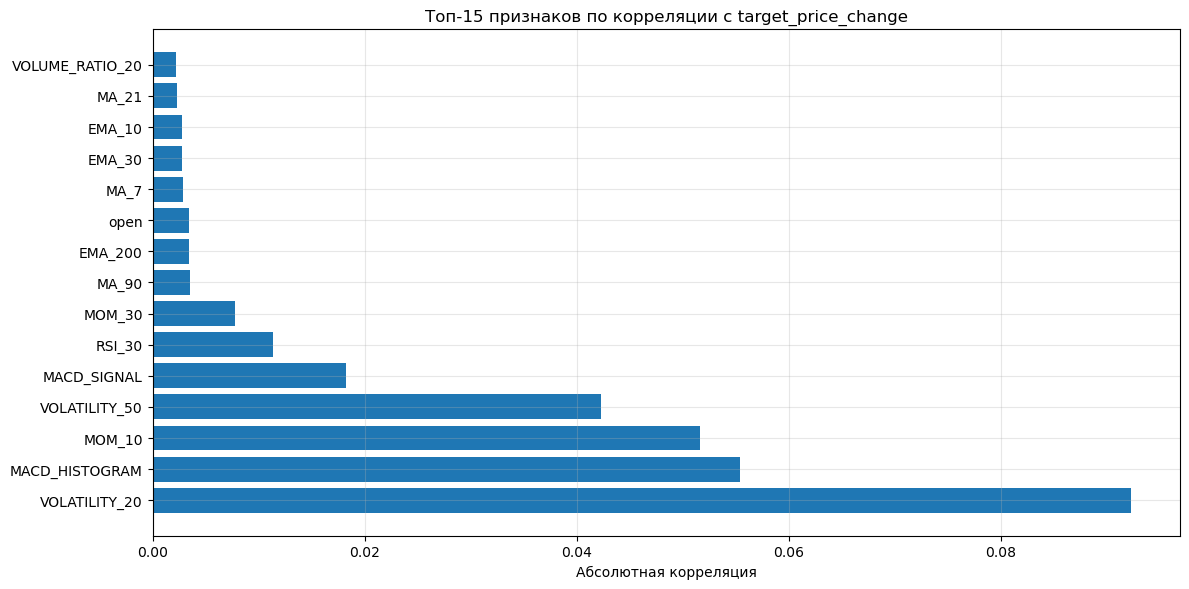

АНАЛИЗ КОРРЕЛЯЦИЙ ПО АКЦИЯМ

SBER - топ-5 корреляций с target_price_change:
  open: -0.394
  MA_7: -0.389
  EMA_10: -0.386
  EMA_30: -0.380
  MA_21: -0.373

GAZP - топ-5 корреляций с target_price_change:
  RSI_200: -0.197
  MA_21: -0.191
  EMA_10: -0.180
  open: -0.178
  MA_7: -0.177

LKOH - топ-5 корреляций с target_price_change:
  open: -0.343
  MA_7: -0.331
  EMA_10: -0.331
  EMA_30: -0.326
  MA_21: -0.318

ROSN - топ-5 корреляций с target_price_change:
  open: -0.246
  EMA_200: -0.246
  MA_7: -0.245
  EMA_10: -0.237
  MA_90: -0.224

YDEX - топ-5 корреляций с target_price_change:
  RSI_200: -0.540
  MACD_HISTOGRAM: -0.533
  open: -0.490
  MOM_10: -0.490
  MA_7: -0.436

VTBR - топ-5 корреляций с target_price_change:
  VOLATILITY_20: 0.202
  EMA_200: -0.162
  MA_21: -0.134
  MA_7: -0.133
  EMA_10: -0.133

TATN - топ-5 корреляций с target_price_change:
  open: -0.371
  MA_7: -0.367
  EMA_10: -0.363
  EMA_30: -0.350
  MA_21: -0.348

GMKN - топ-5 корреляций с target_price_change:
  MOM_1

In [380]:
correlation_results, avg_correlations = analyze_correlations(data)

## Вывод

Есть признаки, очень сильно коррелирующие между собой из за схожиз методов рассчета. Нужно их удалить

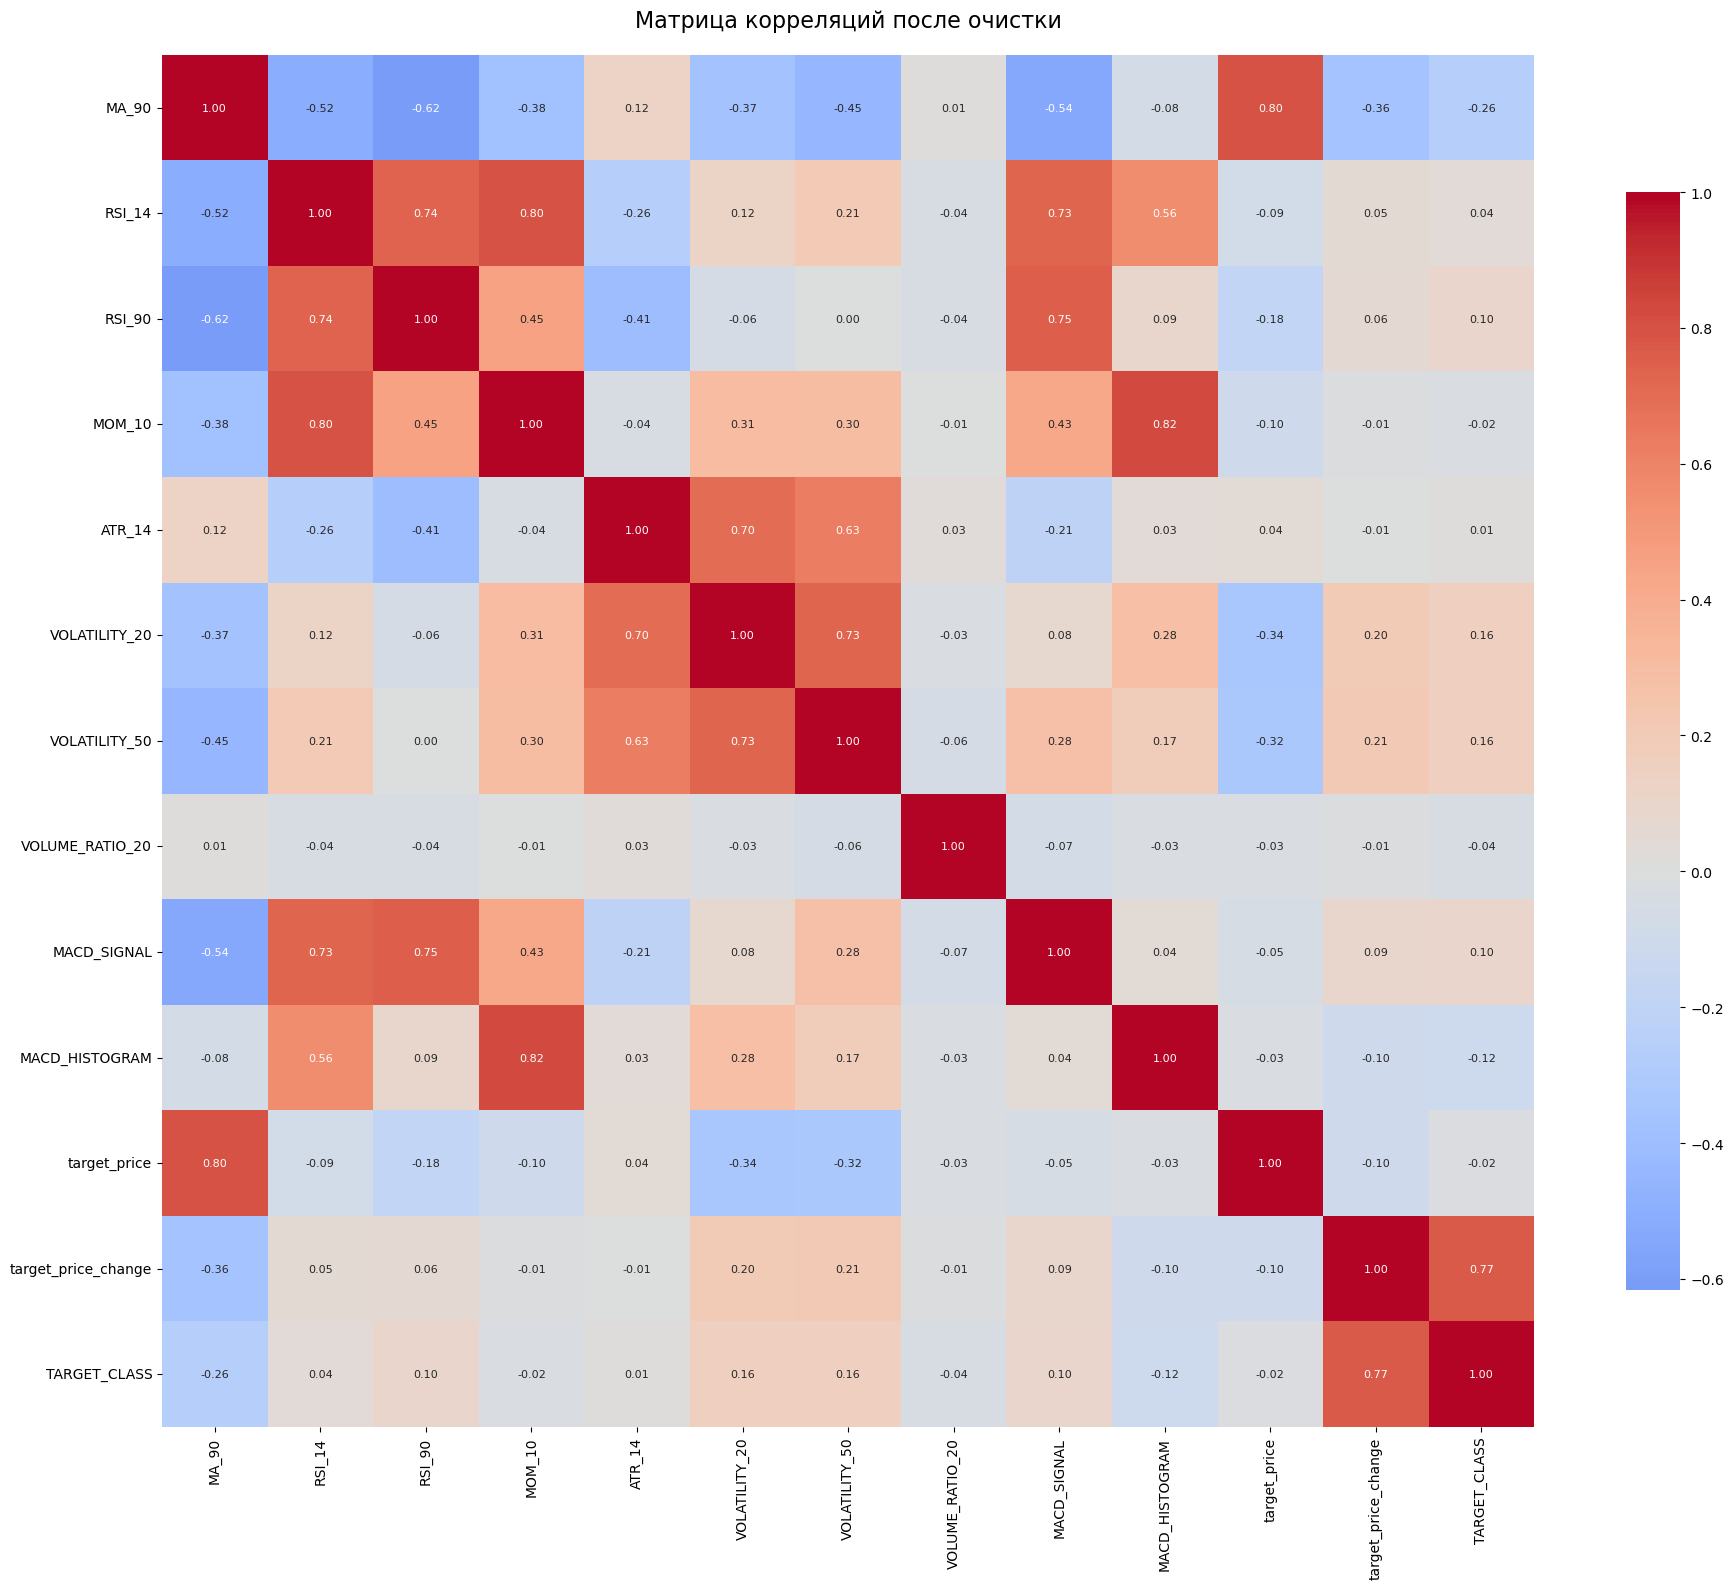

СИЛЬНО КОРРЕЛИРУЮЩИЕ ПАРЫ (|r| > 0.8):
  MOM_10 - MACD_HISTOGRAM: 0.825


In [398]:
_ = plot_correlation_matrix(
    data['SBER'].drop(['MA_7', 'MA_21', 'EMA_10', 'EMA_30', 'EMA_200', 'MOM_30', 'RSI_200', 'MACD', 'RSI_30', 'open'], axis=1), 
    title='Матрица корреляций после очистки')

Удаление сильно коррелирующих признаков (по одному признаку из пары со значением > 0.85)

In [401]:
for ticker in tickers:
    data[ticker].drop(['MA_7', 'MA_21', 'EMA_10', 'EMA_30', 'EMA_200', 'MOM_30', 'RSI_200', 'MACD', 'RSI_30'], axis=1, inplace=True)

У признака RSI_200 очень высокая корреляция с RSI_90, так что можно удалить RSI_200 из-за формирования которого приходилось отрезать первые 200 дат. Это действие прибавит 110 дней к выборке

In [408]:
data['SBER'].columns

Index(['begin', 'open', 'MA_90', 'RSI_14', 'RSI_90', 'MOM_10', 'ATR_14',
       'VOLATILITY_20', 'VOLATILITY_50', 'VOLUME_RATIO_20', 'MACD_SIGNAL',
       'MACD_HISTOGRAM', 'target_price', 'target_price_change',
       'TARGET_CLASS'],
      dtype='object')

## 3.4 Анализ выбросов

АНАЛИЗ ВЫБРОСОВ


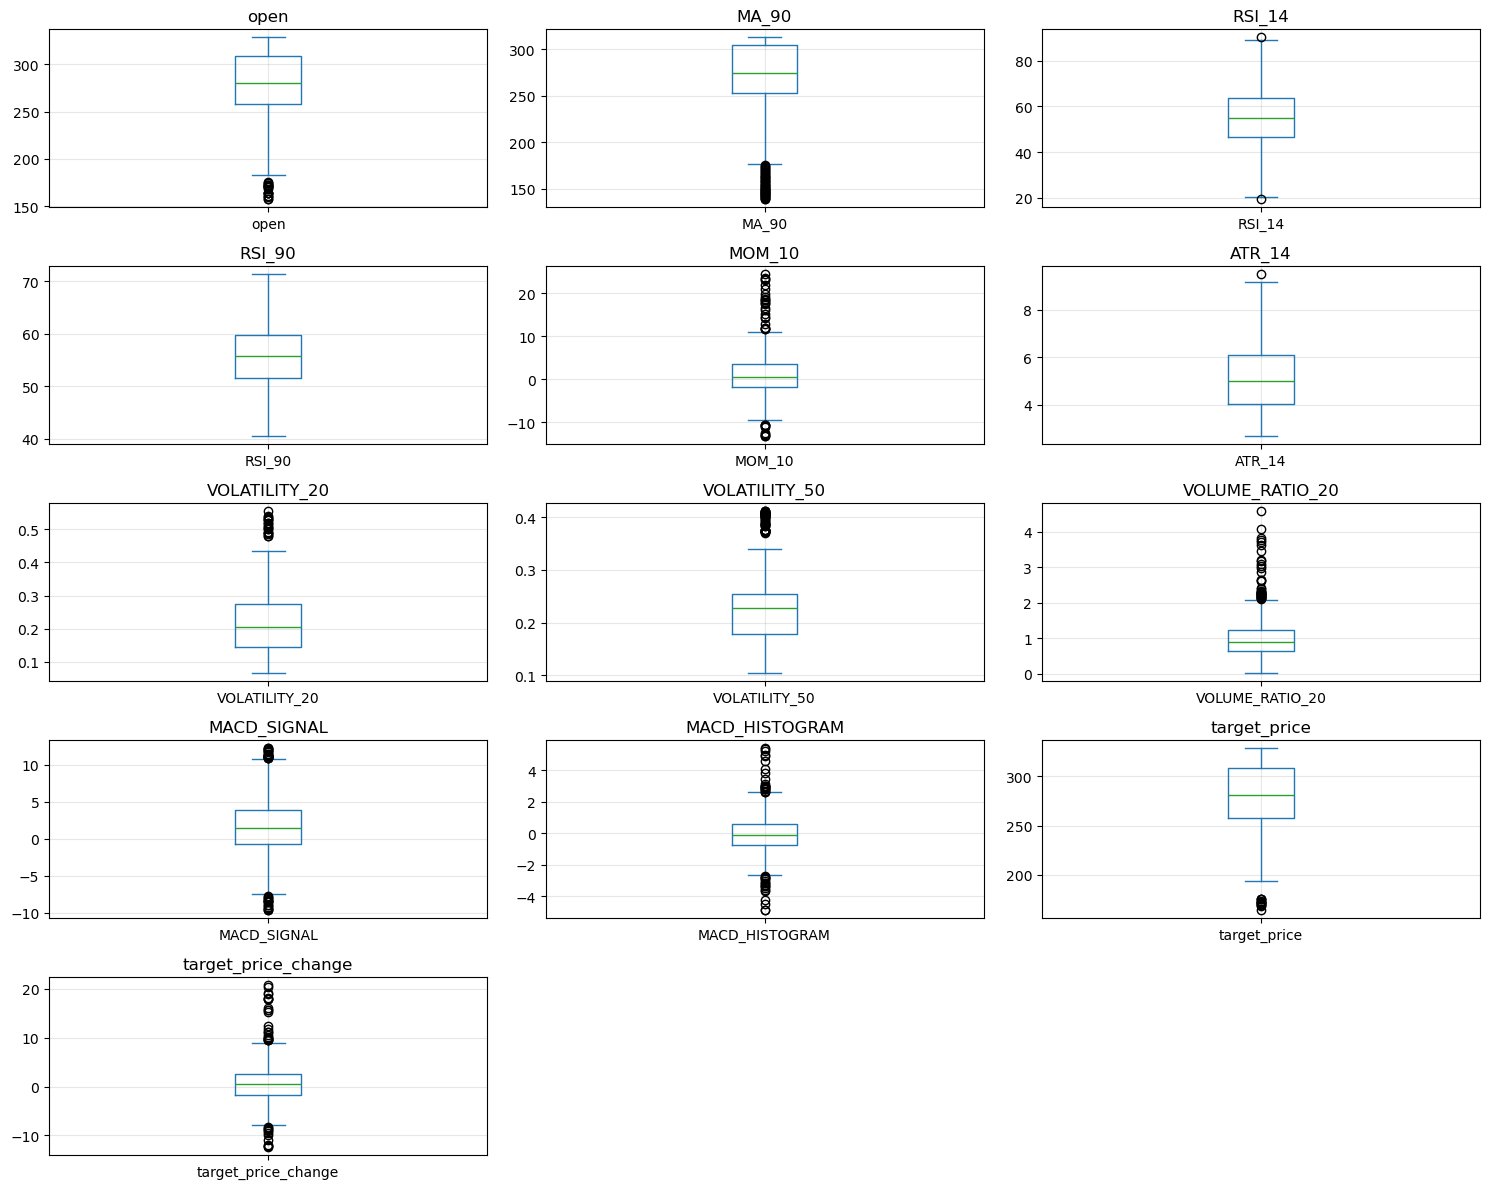


СТАТИСТИКА ВЫБРОСОВ (метод IQR):
--------------------------------------------------
open                 | Выбросы:  21 (  3.0%) | Границы: [ 180.68,  385.80]
MA_90                | Выбросы:  49 (  6.9%) | Границы: [ 175.10,  382.00]
RSI_14               | Выбросы:   2 (  0.3%) | Границы: [  20.31,   89.92]
RSI_90               | Выбросы:   0 (  0.0%) | Границы: [  39.09,   72.27]
MOM_10               | Выбросы:  34 (  4.8%) | Границы: [  -9.76,   11.29]
ATR_14               | Выбросы:   1 (  0.1%) | Границы: [   0.94,    9.21]
VOLATILITY_20        | Выбросы:  20 (  2.8%) | Границы: [  -0.05,    0.47]
VOLATILITY_50        | Выбросы:  50 (  7.1%) | Границы: [   0.06,    0.37]
VOLUME_RATIO_20      | Выбросы:  38 (  5.4%) | Границы: [  -0.23,    2.09]
MACD_SIGNAL          | Выбросы:  39 (  5.5%) | Границы: [  -7.71,   10.89]
MACD_HISTOGRAM       | Выбросы:  40 (  5.6%) | Границы: [  -2.75,    2.59]
target_price         | Выбросы:  14 (  2.0%) | Границы: [ 182.19,  384.91]
target_price_ch

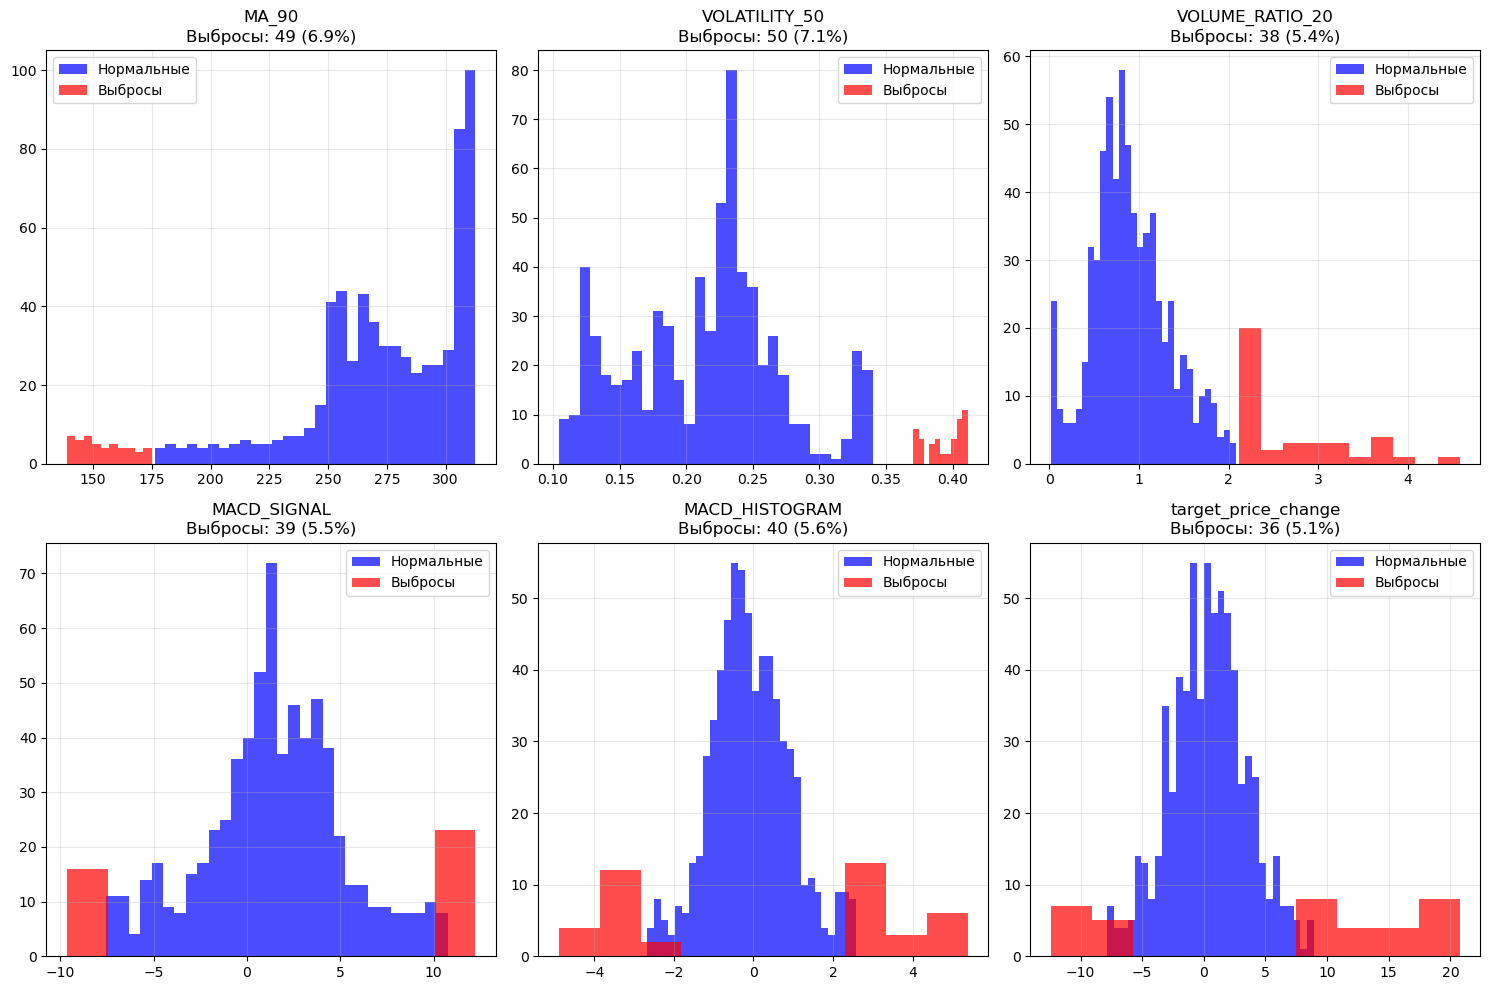


ВЫБРОСЫ В ЦЕЛЕВЫХ ПЕРЕМЕННЫХ:
--------------------------------------------------

target_price: 709 экстремальных движений (>10%)
  Диапазон: 164.3% до 328.4%

target_price_change: 23 экстремальных движений (>10%)
  Диапазон: -12.4% до 20.7%


In [425]:
outlier_stats = analyze_outliers(data['SBER'])

## Вывод

Как и ожадалось, аномальных выбросов в данных нет

## 3.5 Анализ распределений 

### 3.5.1 Сбер

АНАЛИЗ РАСПРЕДЕЛЕНИЙ ПРИЗНАКОВ


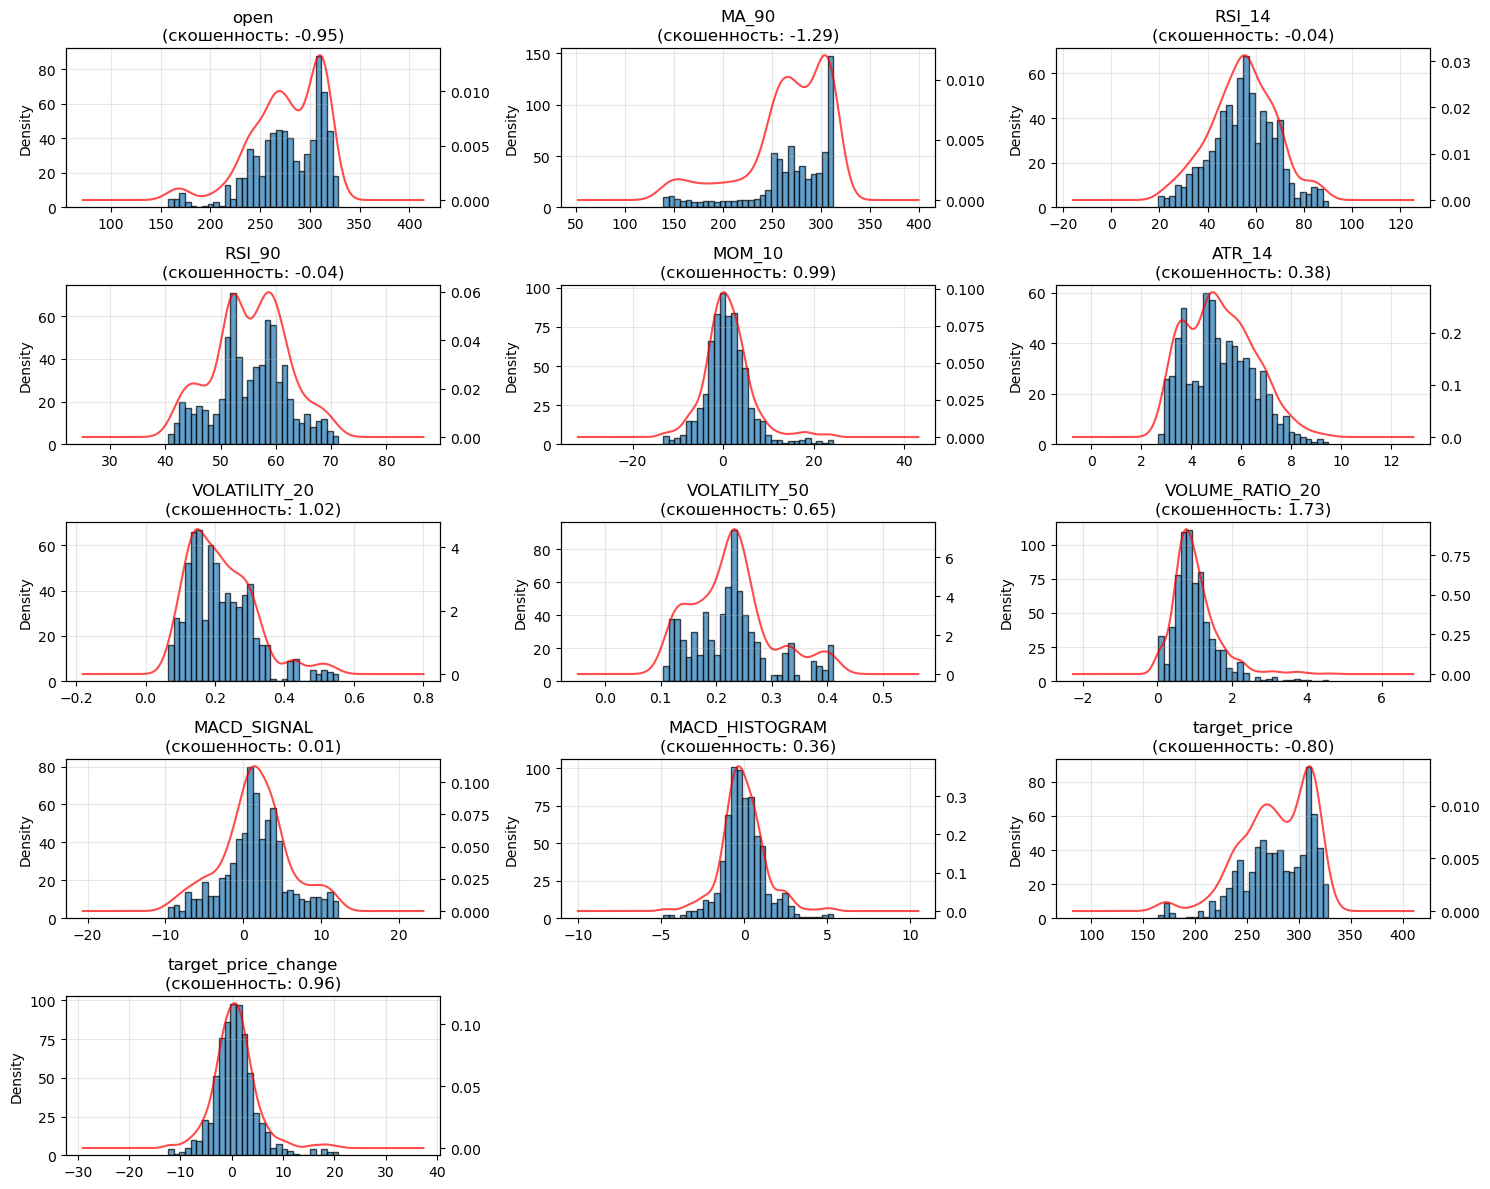


СТАТИСТИКИ РАСПРЕДЕЛЕНИЙ:
----------------------------------------------------------------------
open                 | Скошенность:   -0.95 | Эксцесс:    0.90 | Среднее:   277.53 | Медиана:   280.44
MA_90                | Скошенность:   -1.29 | Эксцесс:    1.13 | Среднее:   267.34 | Медиана:   274.91
RSI_14               | Скошенность:   -0.04 | Эксцесс:   -0.05 | Среднее:    54.77 | Медиана:    55.10
RSI_90               | Скошенность:   -0.04 | Эксцесс:   -0.39 | Среднее:    55.41 | Медиана:    55.81
MOM_10               | Скошенность:    0.99 | Эксцесс:    3.60 | Среднее:     0.99 | Медиана:     0.60
ATR_14               | Скошенность:    0.38 | Эксцесс:   -0.43 | Среднее:     5.15 | Медиана:     5.01
VOLATILITY_20        | Скошенность:    1.02 | Эксцесс:    1.22 | Среднее:     0.22 | Медиана:     0.20
VOLATILITY_50        | Скошенность:    0.65 | Эксцесс:    0.22 | Среднее:     0.23 | Медиана:     0.23
VOLUME_RATIO_20      | Скошенность:    1.73 | Эксцесс:    5.47 | Среднее:     

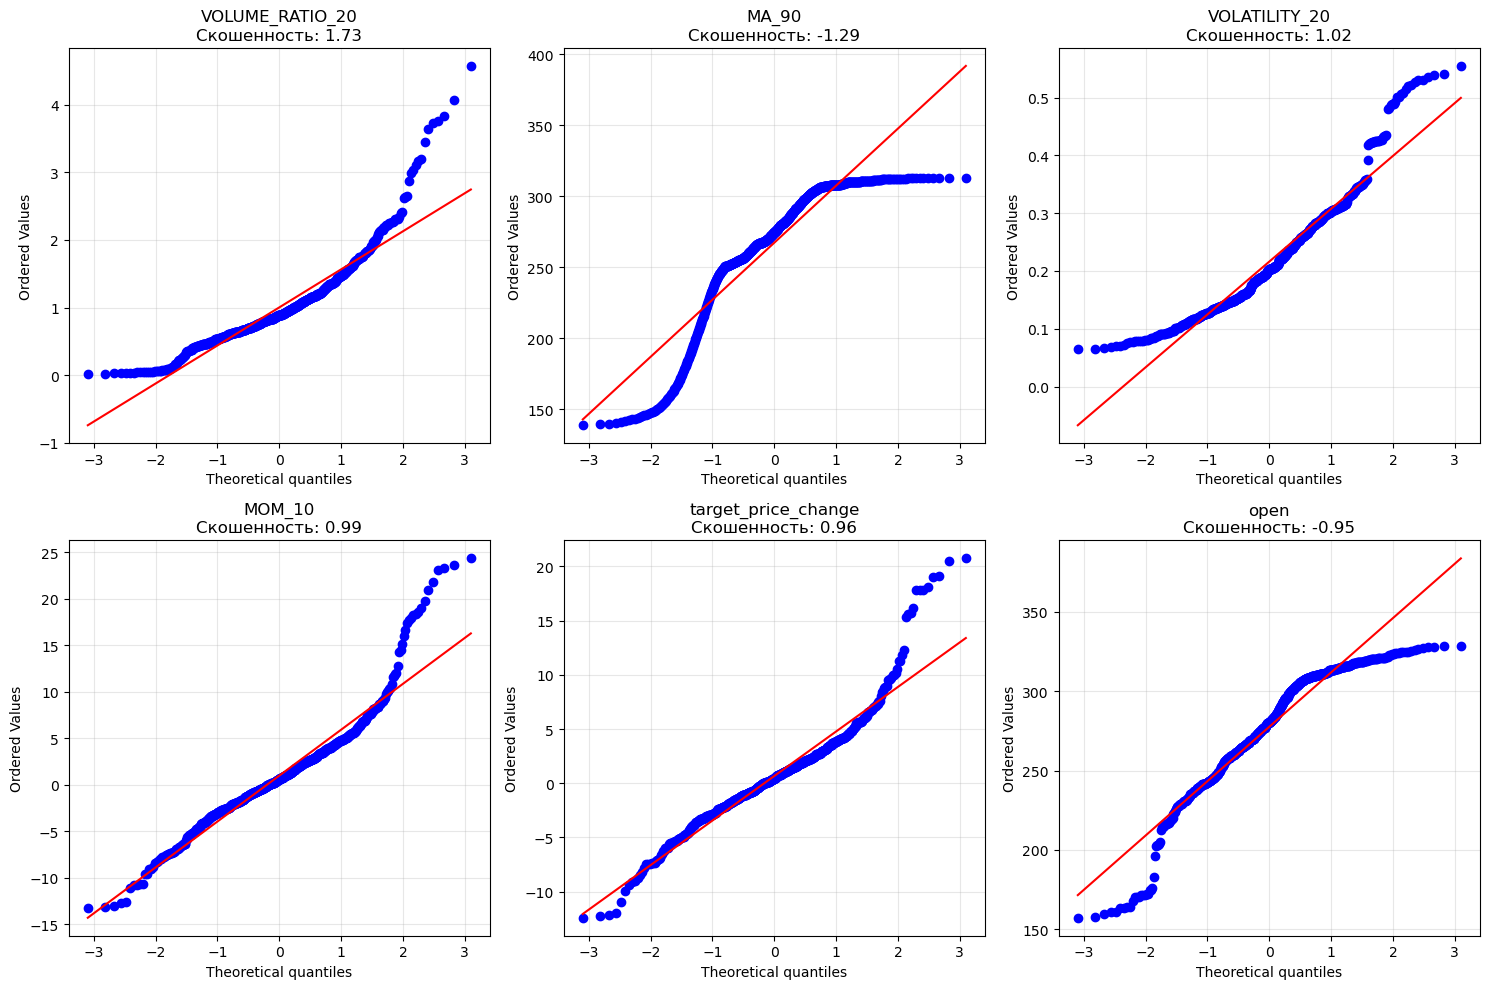


АНАЛИЗ СКОШЕННОСТИ:
--------------------------------------------------

Сильно отрицательная:
  MA_90: -1.29

Умеренно отрицательная:
  open: -0.95
  target_price: -0.80

Примерно нормальное:
  RSI_90: -0.04
  RSI_14: -0.04
  MACD_SIGNAL: 0.01
  MACD_HISTOGRAM: 0.36
  ATR_14: 0.38

Умеренно положительная:
  VOLATILITY_50: 0.65
  target_price_change: 0.96
  MOM_10: 0.99

Сильно положительная:
  VOLATILITY_20: 1.02
  VOLUME_RATIO_20: 1.73

СРАВНЕНИЕ КЛЮЧЕВЫХ ПРИЗНАКОВ:
--------------------------------------------------


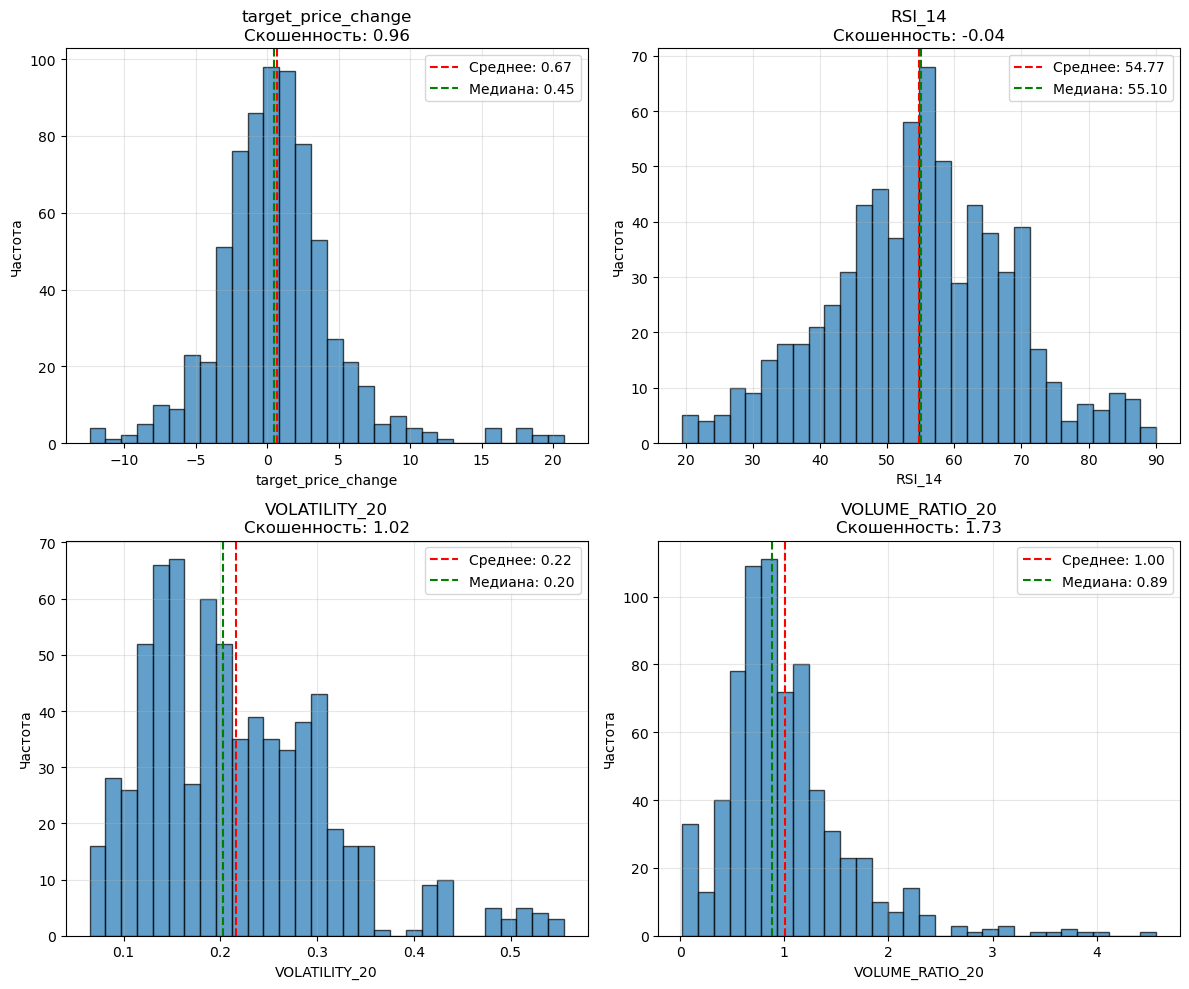


РЕКОМЕНДАЦИИ ПО ПРЕОБРАЗОВАНИЯМ:
--------------------------------------------------
open                 | Скошенность:  -0.95 | Рекомендация: Квадратный корень или Box-Cox
MA_90                | Скошенность:  -1.29 | Рекомендация: Логарифмическое преобразование
MOM_10               | Скошенность:   0.99 | Рекомендация: Квадратный корень или Box-Cox
VOLATILITY_20        | Скошенность:   1.02 | Рекомендация: Логарифмическое преобразование
VOLATILITY_50        | Скошенность:   0.65 | Рекомендация: Квадратный корень или Box-Cox
VOLUME_RATIO_20      | Скошенность:   1.73 | Рекомендация: Логарифмическое преобразование
target_price         | Скошенность:  -0.80 | Рекомендация: Квадратный корень или Box-Cox
target_price_change  | Скошенность:   0.96 | Рекомендация: Квадратный корень или Box-Cox


In [453]:
_, _ = analyze_distributions(data['SBER'])

### Вывод

Распределение у многих признаков похоже на нормальное, в остальных случаях распредления все равно выглядят достаточно хорошо. Так же, в дальнейшем, можно будет применить неккоторые преобраозования чтобы привести распределения к более нормальному виду, если это потребуется

### 3.5.2 Все вместе 

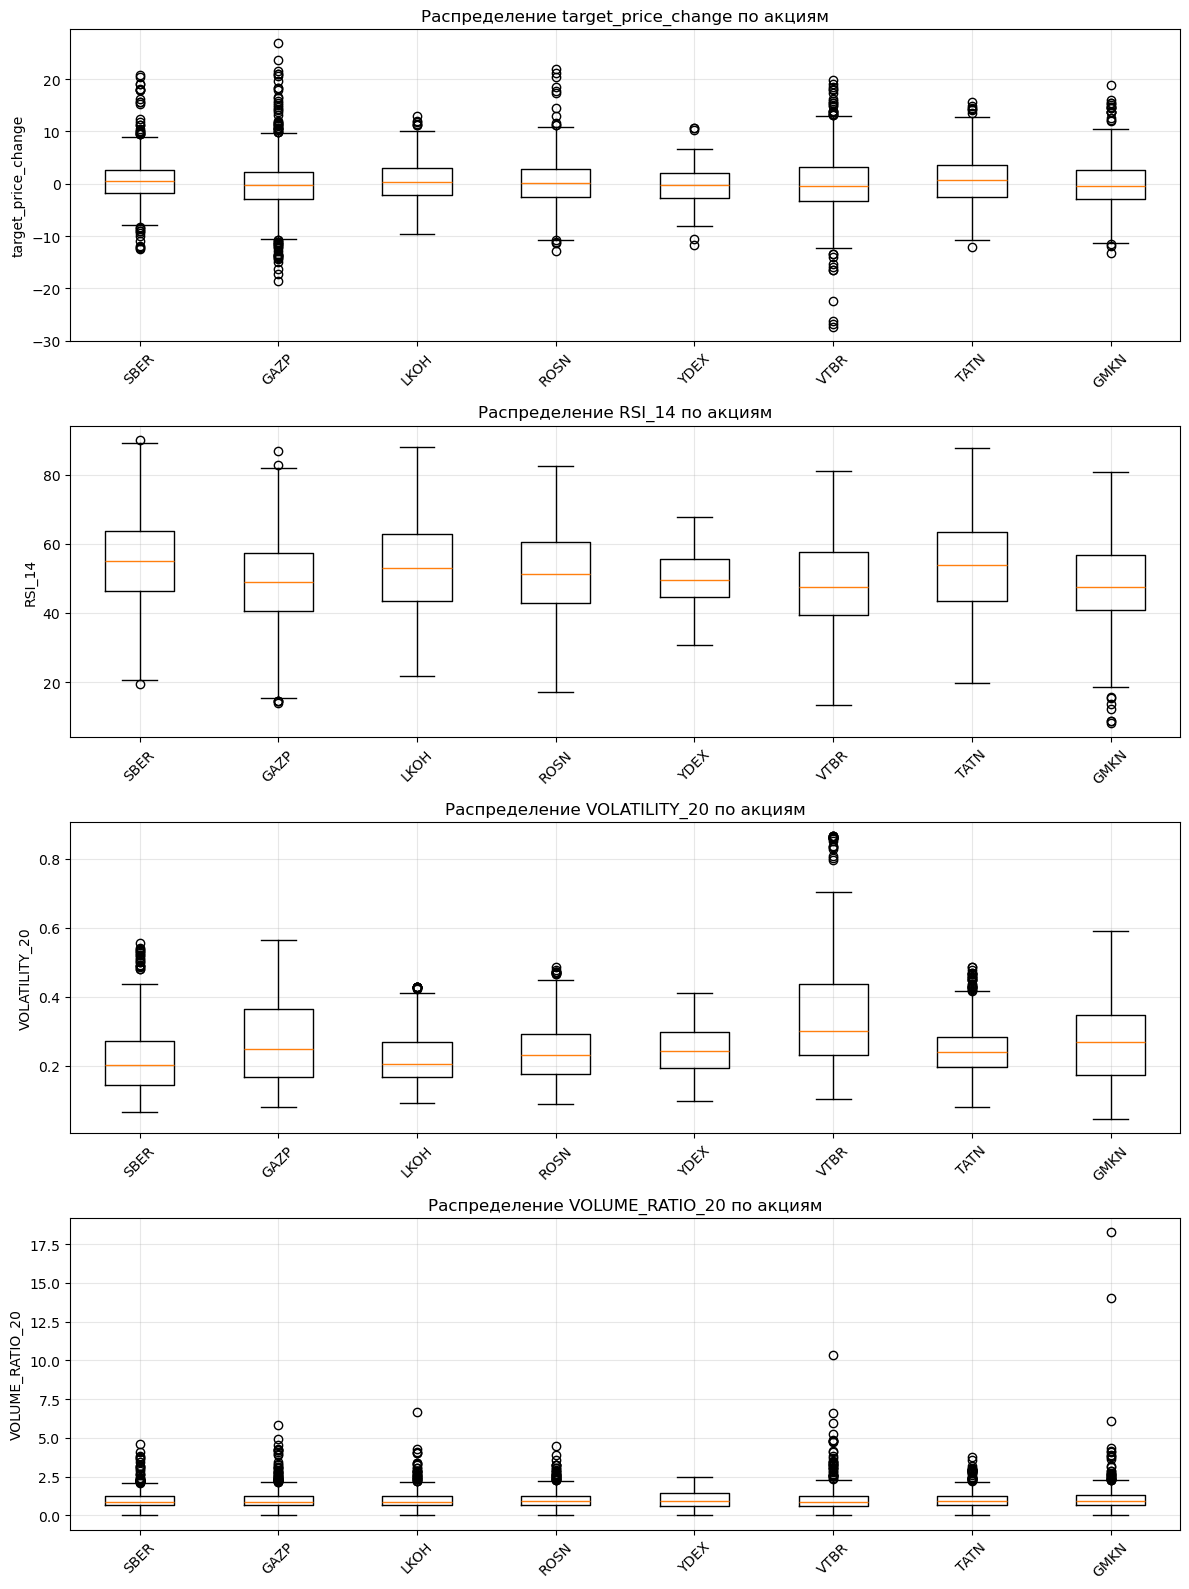

СТАТИСТИКИ ПО АКЦИЯМ:
--------------------------------------------------

target_price_change:
  SBER: среднее=0.67, ст.откл=4.25, скошенность=0.96
  GAZP: среднее=-0.11, ст.откл=5.63, скошенность=0.71
  LKOH: среднее=0.53, ст.откл=3.91, скошенность=0.22
  ROSN: среднее=0.29, ст.откл=4.67, скошенность=0.56
  YDEX: среднее=-0.27, ст.откл=3.83, скошенность=0.11
  VTBR: среднее=0.03, ст.откл=6.18, скошенность=-0.02
  TATN: среднее=0.79, ст.откл=4.62, скошенность=0.21
  GMKN: среднее=-0.05, ст.откл=4.80, скошенность=0.43

RSI_14:
  SBER: среднее=54.77, ст.откл=13.45, скошенность=-0.04
  GAZP: среднее=48.17, ст.откл=12.37, скошенность=-0.27
  LKOH: среднее=53.56, ст.откл=12.95, скошенность=0.17
  ROSN: среднее=51.89, ст.откл=12.63, скошенность=0.12
  YDEX: среднее=49.92, ст.откл=8.08, скошенность=0.01
  VTBR: среднее=48.45, ст.откл=12.96, скошенность=0.03
  TATN: среднее=53.65, ст.откл=13.64, скошенность=-0.03
  GMKN: среднее=48.77, ст.откл=12.17, скошенность=0.03

VOLATILITY_20:
  SBER: ср

In [448]:
compare_distributions_across_stocks(data)

### Вывод

На самом деле, без предварительной нормироваки, такое сравнение может быть не информативным

## 3.6 Анализ взаимосвязей

АНАЛИЗ ВЗАИМОСВЯЗЕЙ И ПАТТЕРНОВ

1. PAIRPLOT КЛЮЧЕВЫХ ПРИЗНАКОВ
----------------------------------------


<Figure size 1200x1000 with 0 Axes>

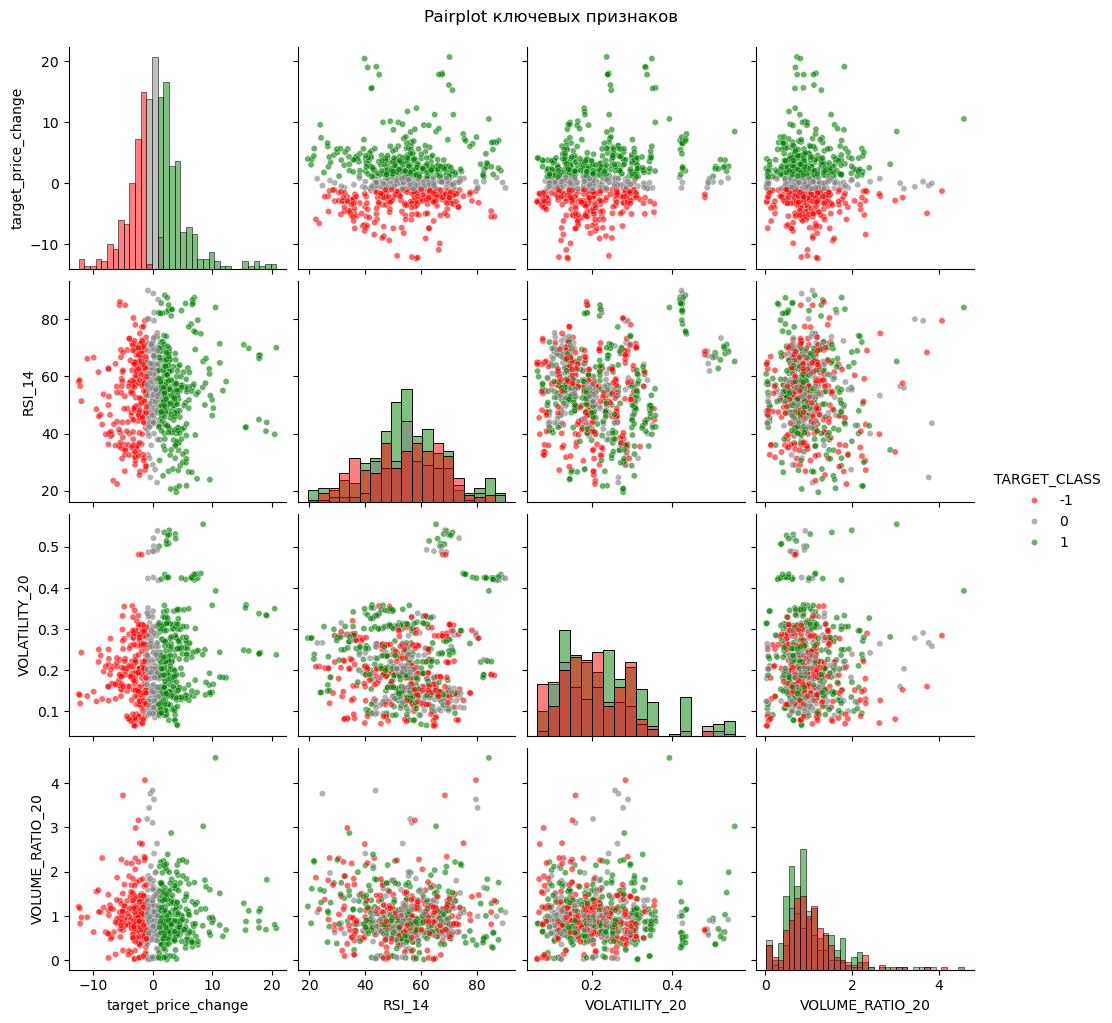


2. SCATTER PLOT С ЦЕЛЕВЫМИ ПЕРЕМЕННЫМИ
----------------------------------------


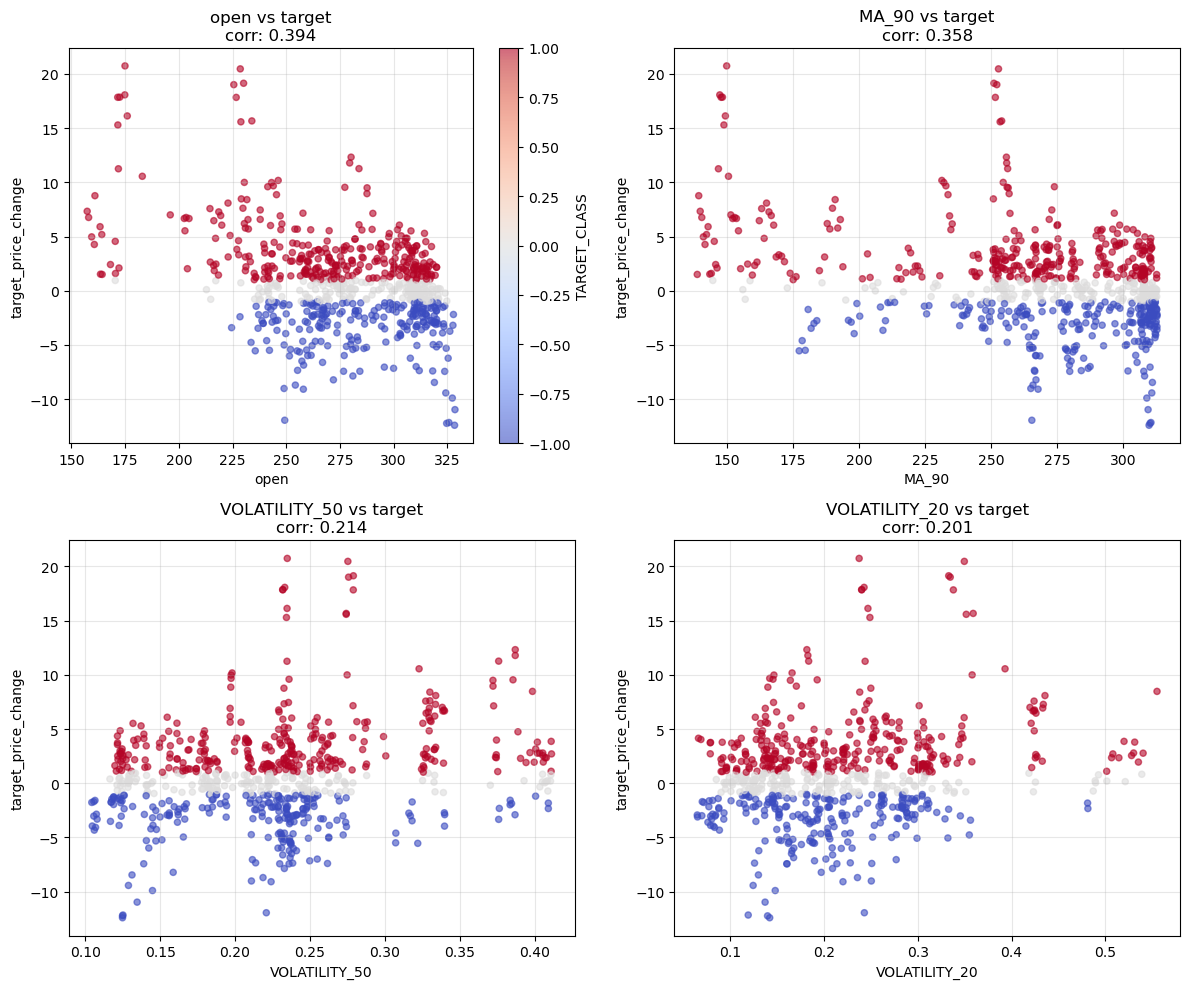


3. ПРЕДВАРИТЕЛЬНАЯ ОЦЕНКА ВАЖНОСТИ ПРИЗНАКОВ
----------------------------------------


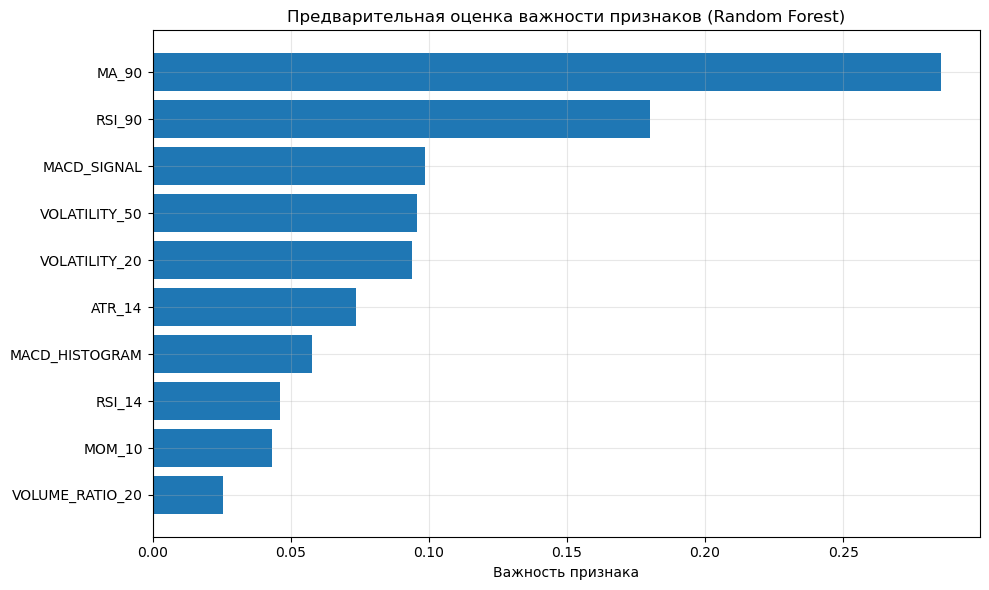

Топ-10 важных признаков:
  MA_90               : 0.285
  RSI_90              : 0.180
  MACD_SIGNAL         : 0.098
  VOLATILITY_50       : 0.096
  VOLATILITY_20       : 0.094
  ATR_14              : 0.073
  MACD_HISTOGRAM      : 0.058
  RSI_14              : 0.046
  MOM_10              : 0.043
  VOLUME_RATIO_20     : 0.026


In [474]:
_ = analyze_relationships(data['SBER'])

## Вывод

Визуально зависимость между признаками и целевой переменной определить не удалось, можно предварительно рассчитать важность признаков

## 3.7 Анализ динамики по отраслям

СРАВНЕНИЕ РАСПРЕДЕЛЕНИЙ ПО ОТРАСЛЯМ
Финансы: 2 компаний
Нефтегаз: 3 компаний
Металлы: 2 компаний

Анализируемые признаки: ['RSI_14', 'VOLUME_RATIO_20', 'target_price_change', 'VOLATILITY_20', 'MOM_10', 'ATR_14']


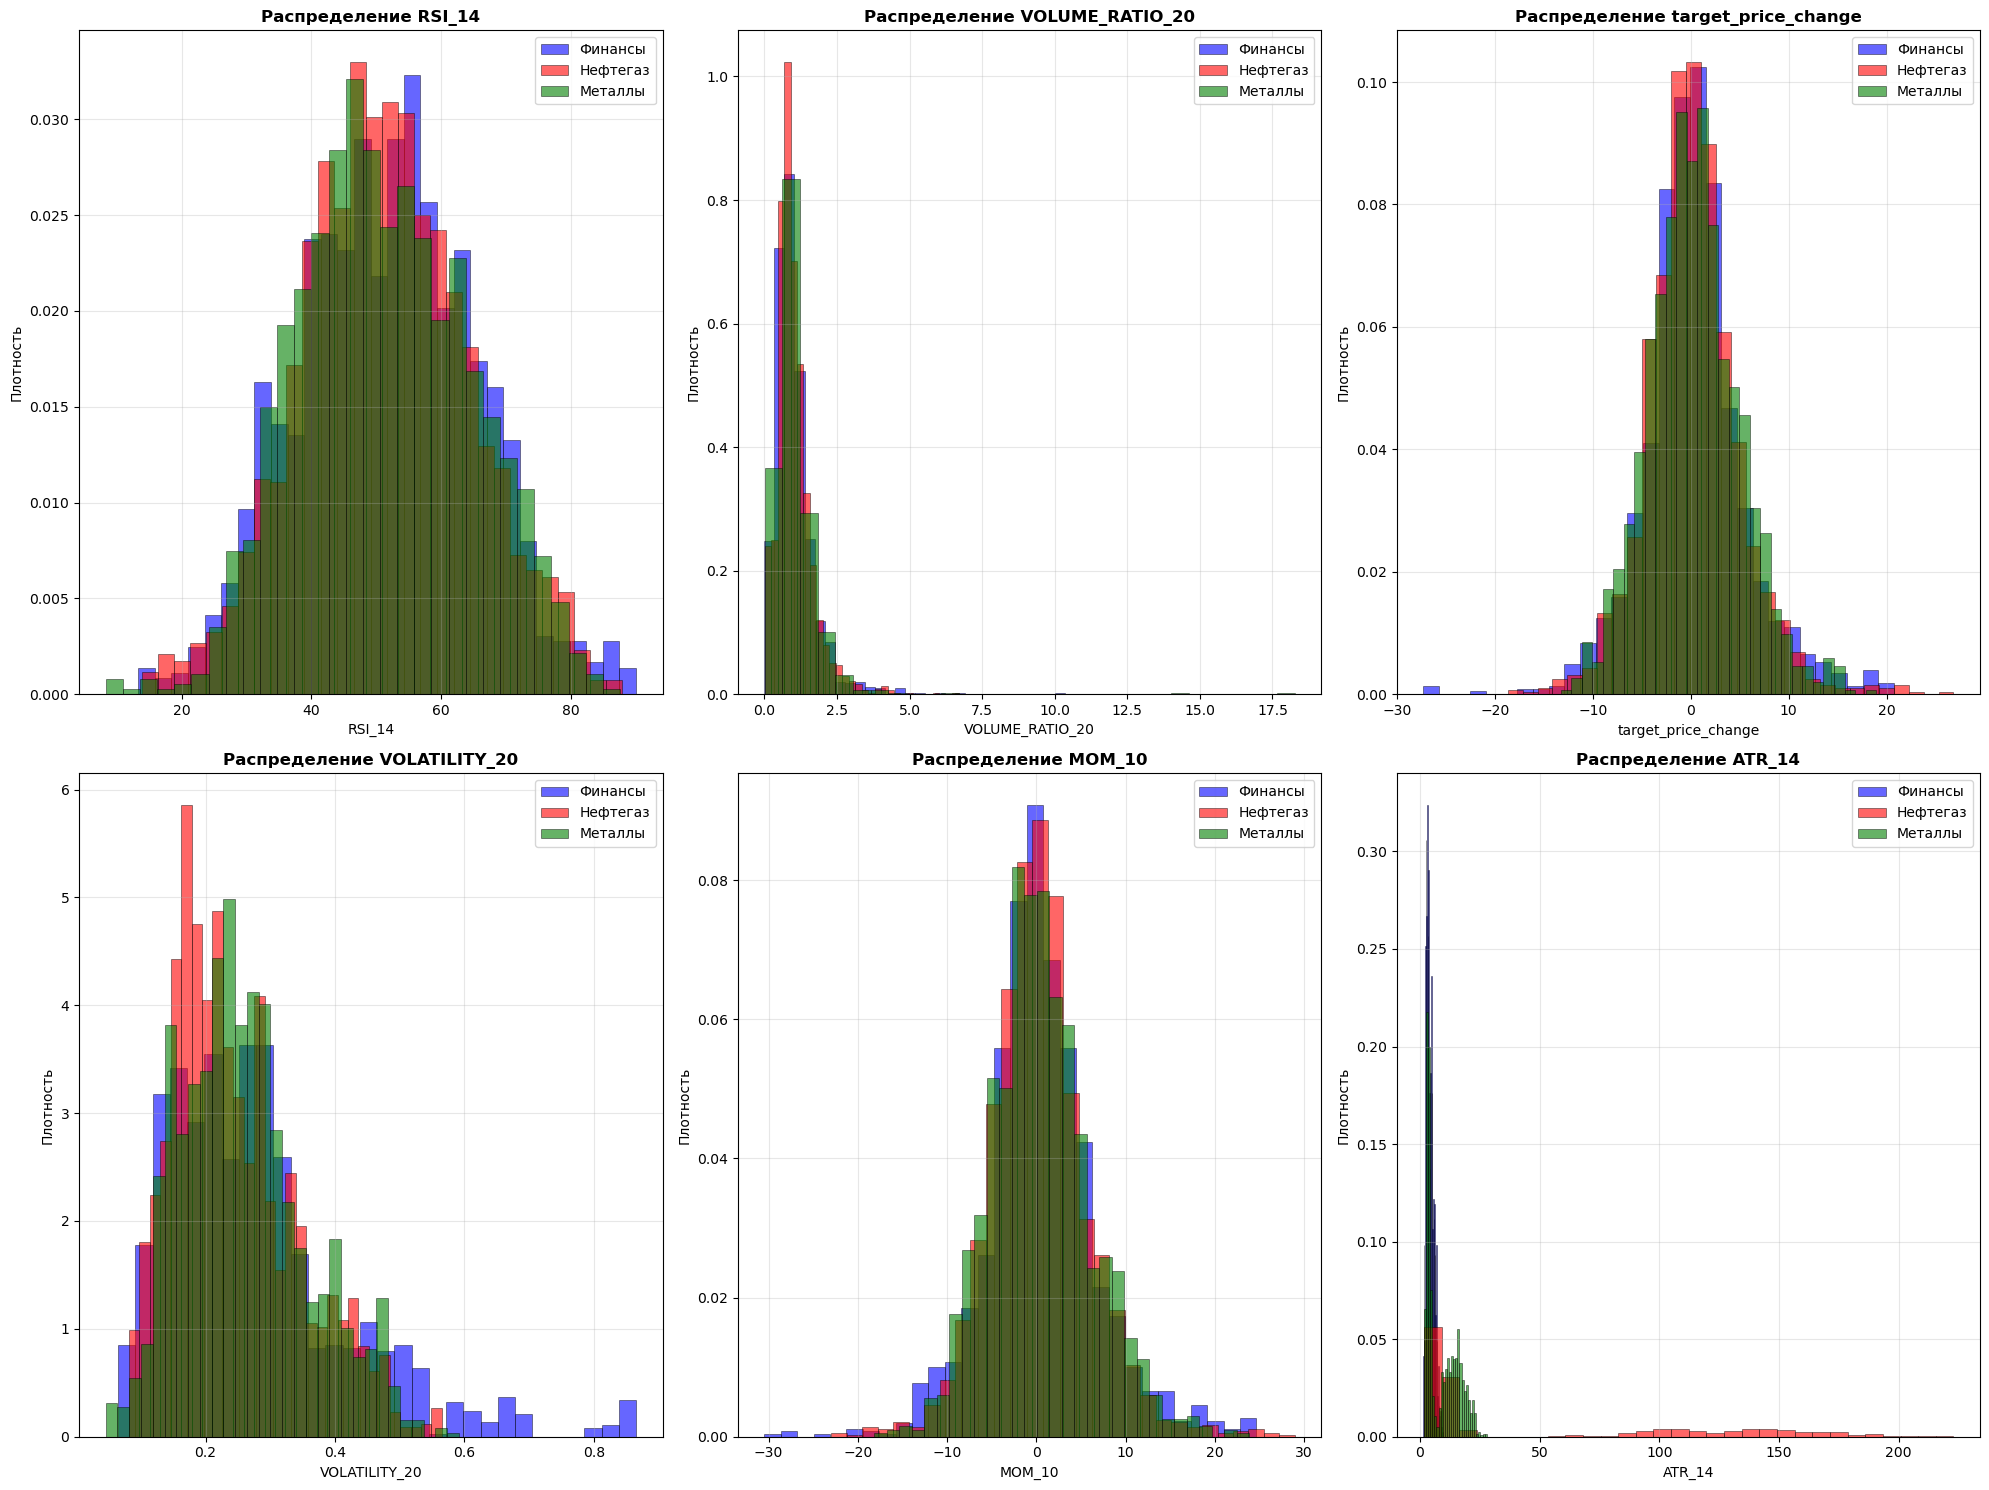


СТАТИСТИКИ ПО ОТРАСЛЯМ

RSI_14:
----------------------------------------
  Нефтегаз        | Среднее:  51.204 | Ст.откл:  12.847 | Скошенность:   0.03
  Металлы         | Среднее:  51.212 | Ст.откл:  13.152 | Скошенность:   0.05
  Финансы         | Среднее:  51.620 | Ст.откл:  13.576 | Скошенность:   0.02

VOLUME_RATIO_20:
----------------------------------------
  Финансы         | Среднее:   1.018 | Ст.откл:   0.745 | Скошенность:   3.37
  Нефтегаз        | Среднее:   1.022 | Ст.откл:   0.643 | Скошенность:   2.14
  Металлы         | Среднее:   1.046 | Ст.откл:   0.841 | Скошенность:   9.35

target_price_change:
----------------------------------------
  Нефтегаз        | Среднее:   0.240 | Ст.откл:   4.791 | Скошенность:   0.54
  Финансы         | Среднее:   0.350 | Ст.откл:   5.309 | Скошенность:   0.16
  Металлы         | Среднее:   0.371 | Ст.откл:   4.725 | Скошенность:   0.31

VOLATILITY_20:
----------------------------------------
  Нефтегаз        | Среднее:   0.245 | Ст.отк

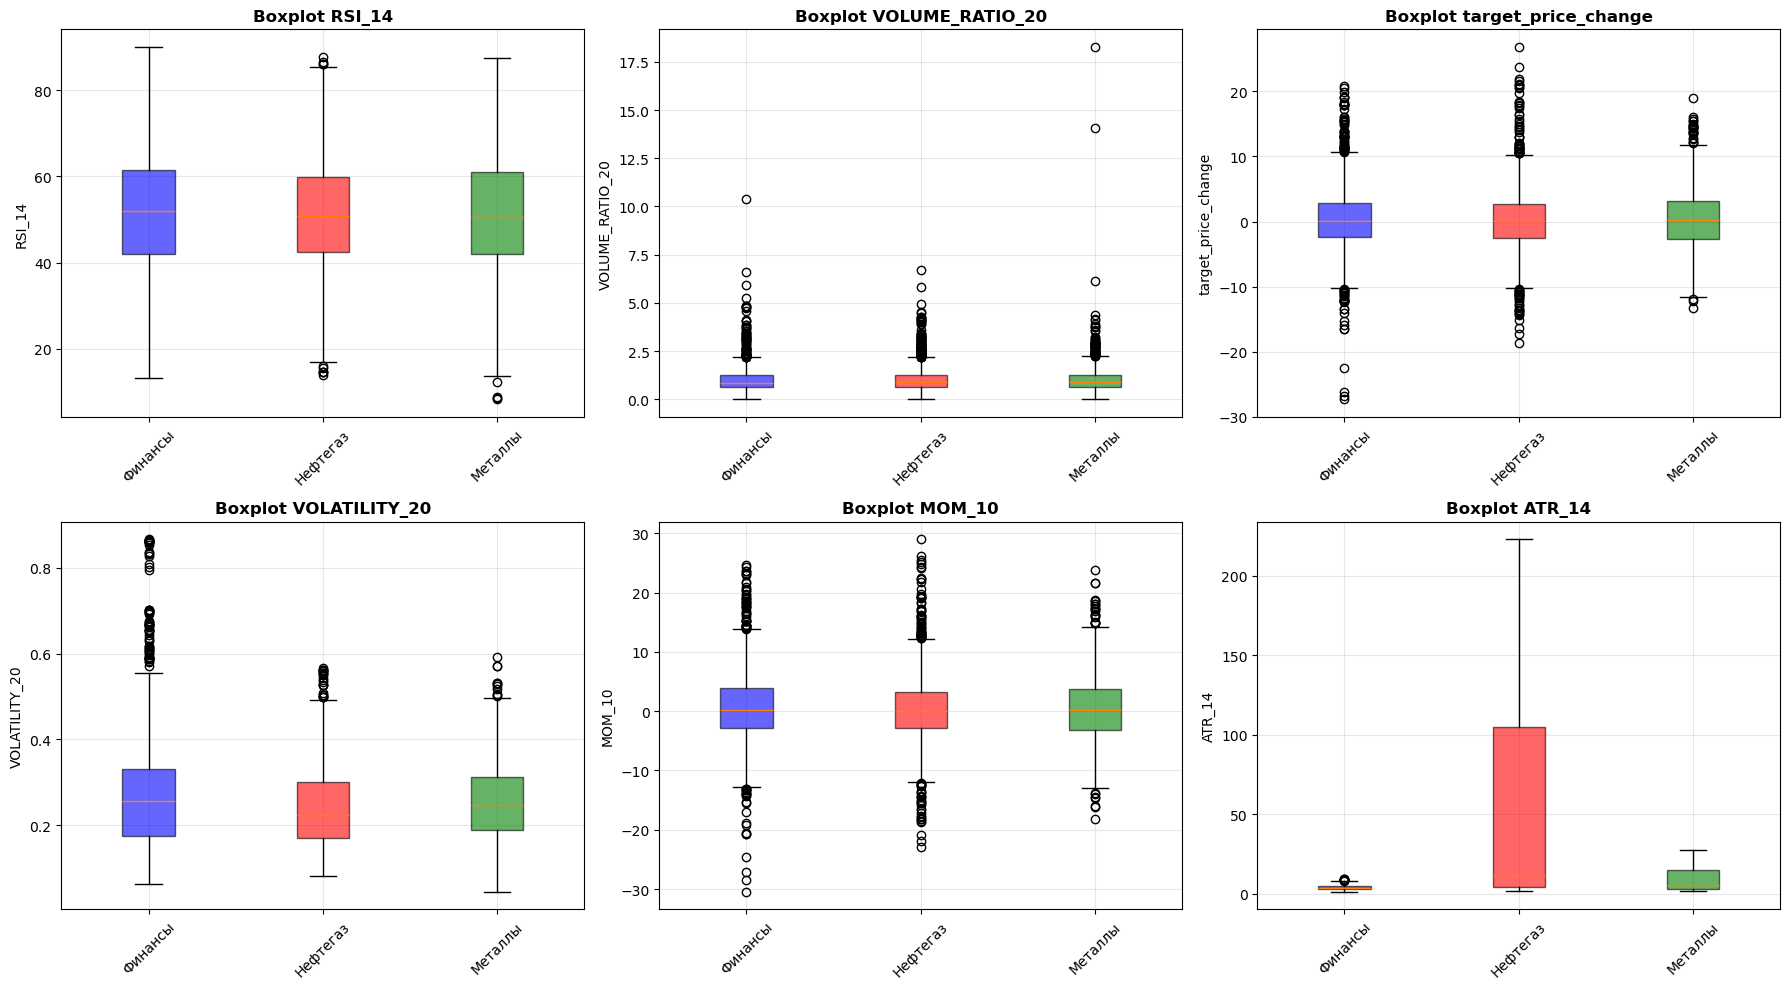

In [483]:
industry_tickers = create_industry_groups()
industry_data = compare_industries_distributions(data, industry_tickers)

## Вывод

Видно, что распределение многих признаков очень похоже по некоторым отраслям, но например для признака ATR_14 оно различаестя </br>
Это еще раз наталкивает на мысль, что может потребоваться обучать различные модели для конкретных групп ценных бумаг